# Analyse complète — Incremental vs Online_newjob vs Hybrid-n_j (2026-10-07)

Protocole single-decision-point : un état A gelé (n_existing jobs déjà en place, construit via un
vrai dispatch SimPy live), puis un nouveau job arrive à mi-vie du batch (max_flow_time/2 + 200).
Les 3 approches décident de son placement à partir du même état A figé, sans contamination entre
elles (vérifié).

- **Phase A** : 3 paliers de taille (petit/grand/mixte) à échelle x2 fixe, puis le palier mixte
  seul balayé en échelle x0.5/x2/x4/x6 — `n_existing=5` fixe, 50 nœuds.
- **Phase B** : palier mixte x2 fixe, `n_existing` ∈ {2,5,10,15} — 50 nœuds.
- **Phase C** : 5 scénarios totalement aléatoires (nb_nodes∈[10,30], n_existing∈[2,15], plages de
  taille/durée aléatoires), avec un plancher forçant le nouveau job à ne jamais être petit.

Budgets solveur : état A=30s, Incremental=défaut, Online_newjob=30s, Hybrid F1=15s +
escalade=30s (11 variantes concurrentes), plafond de dégradation=25%, mono-objectif
(`adaptive_bi_objective=False`).

In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("results-validation-2026-10-07/phaseABC_full_metrics.csv")
df = df[df.no_solution != True].copy()

APPROACH_DISPLAY = {"incremental": "Incremental", "online_newjob": "Online_newjob", "hybrid": "Hybrid-n_j"}
df["approach_disp"] = df["approach"].map(APPROACH_DISPLAY)
colors = {"Incremental": "#8C8C8C", "Online_newjob": "#4472C4", "Hybrid-n_j": "#2E8B57"}
order = ["Incremental", "Online_newjob", "Hybrid-n_j"]

PHASE_LABEL = {"A": "Phase A (palier/échelle)", "B": "Phase B (n_existing)", "C": "Phase C (aléatoire)"}
df["phase_label"] = df["phase"].map(PHASE_LABEL)

def scenario_label(row):
    if row.phase == "A":
        return f"{row.group}:{row.tag}"
    return row.tag

df["scenario"] = df.apply(scenario_label, axis=1)

def grouped_bar(ax, data, value_col, title, ylabel):
    scenarios = sorted(data["scenario"].unique(), key=lambda s: (len(s), s))
    x = np.arange(len(scenarios))
    width = 0.25
    for i, appr in enumerate(order):
        sub = data[data.approach_disp == appr].set_index("scenario").reindex(scenarios)[value_col]
        ax.bar(x + (i - 1) * width, sub.values, width, label=appr, color=colors[appr])
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

print(f"{len(df)} lignes chargées, phases: {sorted(df.phase.unique())}")
df.head()

48 lignes chargées, phases: ['A', 'B', 'C']


,phase,group,tag,n_existing,nb_nodes,new_job_dataset_size,new_job_nb_tasks,new_job_task_duration,dataset_size_range_lo,dataset_size_range_hi,...,max_flow_time_all_pre_patch,transfer_energy_total_pre_patch,nb_transfers_total_pre_patch,nb_transfers_new_job_pre_patch,nb_nodes_used_new_job_pre_patch,nb_nodes_used_total_pre_patch,data_transferred_new_job_mb_pre_patch,approach_disp,phase_label,scenario
0,A,palier,petit,5,50,34903,18,282,4096,40960,...,2106.0,1066.779032,9,9,9,9,314127,Incremental,Phase A (palier/échelle),palier:petit
1,A,palier,petit,5,50,34903,18,282,4096,40960,...,2107.0,1063.177725,10,9,9,10,314127,Online_newjob,Phase A (palier/échelle),palier:petit
2,A,palier,petit,5,50,34903,18,282,4096,40960,...,2106.0,1066.779032,9,9,9,9,314127,Hybrid-n_j,Phase A (palier/échelle),palier:petit
3,A,palier,grand,5,50,389472,19,594,204800,409600,...,10799.0,13008.869344,7,7,7,7,2726304,Incremental,Phase A (palier/échelle),palier:grand
4,A,palier,grand,5,50,389472,19,594,204800,409600,...,11028.0,20679.604964,16,8,8,12,3115776,Online_newjob,Phase A (palier/échelle),palier:grand


## 1. Flow time — nouveau job et reste du système

`flow_time_new_job` : la métrique principale (ce qu'on optimise).
`mean_flow_time_all` / `max_flow_time_all` : impact sur TOUS les jobs du batch reconsidéré —
Incremental ne touche jamais aux jobs existants, Online_newjob/Hybrid le peuvent (sous plafond de
dégradation de 25%).

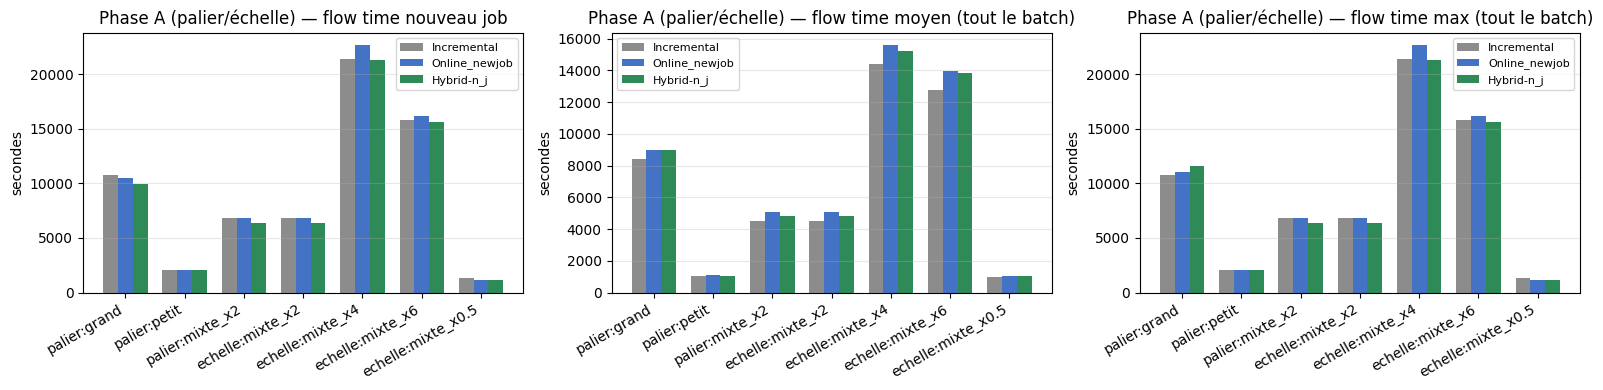

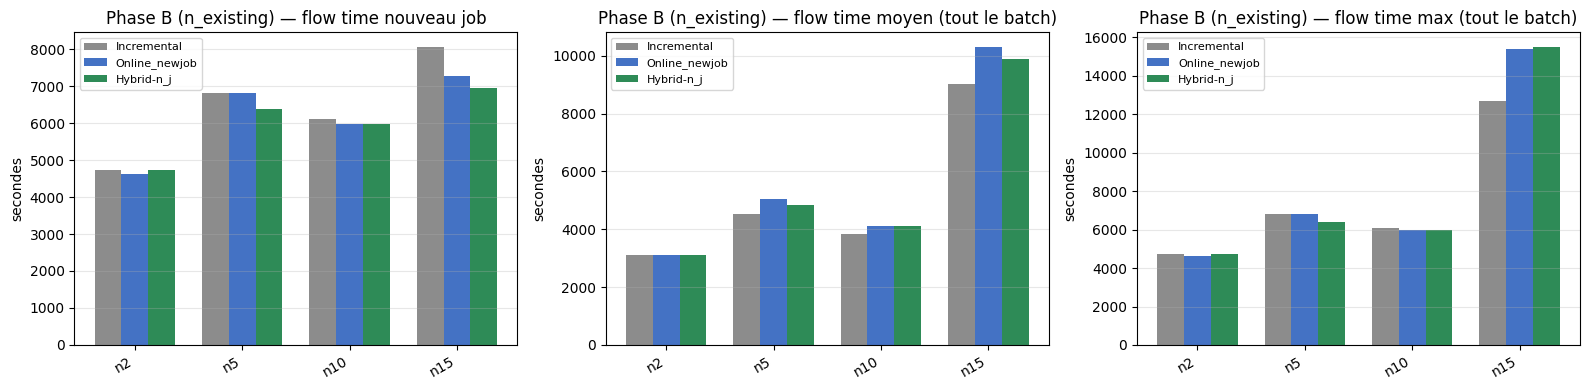

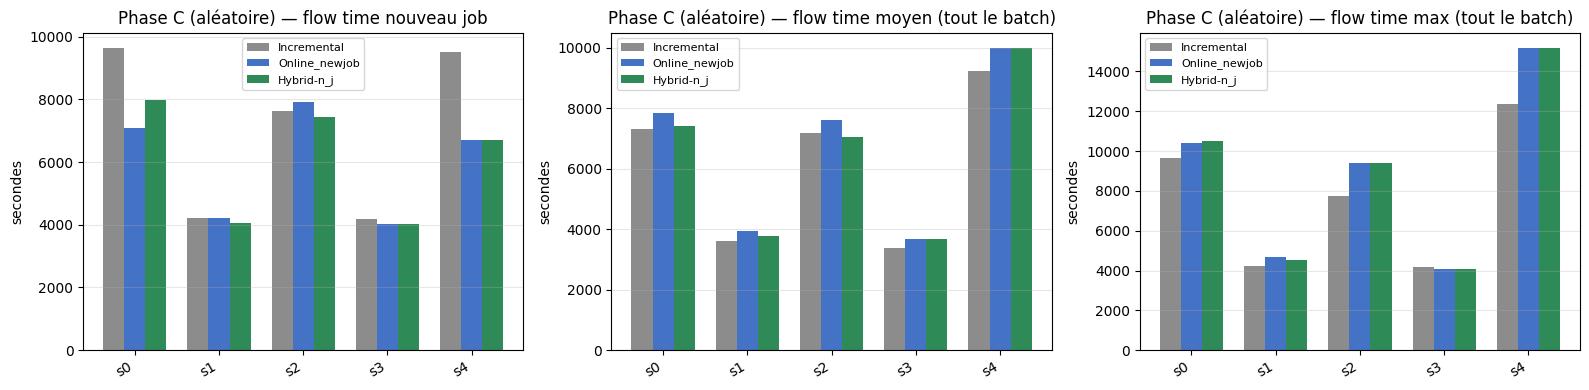

In [2]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    grouped_bar(axes[0], sub, "flow_time_new_job", f"{PHASE_LABEL[phase]} — flow time nouveau job", "secondes")
    grouped_bar(axes[1], sub, "mean_flow_time_all", f"{PHASE_LABEL[phase]} — flow time moyen (tout le batch)", "secondes")
    grouped_bar(axes[2], sub, "max_flow_time_all", f"{PHASE_LABEL[phase]} — flow time max (tout le batch)", "secondes")
    plt.tight_layout()
    plt.show()

In [3]:
print("Gain Hybrid vs Incremental sur flow_time_new_job, par scénario :")
pivot = df.pivot_table(index=["phase", "scenario"], columns="approach", values="flow_time_new_job")
pivot["gain_hybrid_pct"] = (pivot["incremental"] - pivot["hybrid"]) / pivot["incremental"] * 100
pivot["gain_online_newjob_pct"] = (pivot["incremental"] - pivot["online_newjob"]) / pivot["incremental"] * 100
pivot.round(1)

Gain Hybrid vs Incremental sur flow_time_new_job, par scénario :


approach                   hybrid  incremental  online_newjob  \
phase scenario                                                  
A     echelle:mixte_x0.5   1131.0       1351.0         1131.0   
      echelle:mixte_x2     6379.0       6816.0         6817.0   
      echelle:mixte_x4    21285.0      21414.0        22660.0   
      echelle:mixte_x6    15581.0      15812.0        16192.0   
      palier:grand         9946.0      10799.0        10530.0   
      palier:mixte_x2      6379.0       6816.0         6817.0   
      palier:petit         2106.0       2106.0         2107.0   
B     n10                  5967.0       6099.0         5967.0   
      n15                  6953.0       8050.0         7261.0   
      n2                   4730.0       4730.0         4633.0   
      n5                   6379.0       6816.0         6817.0   
C     s0                   7987.0       9641.0         7081.0   
      s1                   4072.0       4206.0         4204.0   
      s2                   7442.0       7640.0         7931.0   
      s3                   4009.0       4184.0         4009.0   
      s4                   6713.0       9520.0         6713.0   

approach                  gain_hybrid_pct  gain_online_newjob_pct  
phase scenario                                                     
A     echelle:mixte_x0.5             16.3                    16.3  
      echelle:mixte_x2                6.4                    -0.0  
      echelle:mixte_x4                0.6                    -5.8  
      echelle:mixte_x6                1.5                    -2.4  
      palier:grand                    7.9                     2.5  
      palier:mixte_x2                 6.4                    -0.0  
      palier:petit                    0.0                    -0.0  
B     n10                             2.2                     2.2  
      n15                            13.6                     9.8  
      n2                              0.0                     2.1  
      n5                              6.4                    -0.0  
C     s0                             17.2                    26.6  
      s1                              3.2                     0.0  
      s2                              2.6                    -3.8  
      s3                              4.2                     4.2  
      s4                             29.5                    29.5

## 2. Nombre de transferts

`nb_transfers_new_job` : combien de répliques (nœuds différents) le nouveau job reçoit — un
chiffre élevé signifie que l'approche étale ses tâches sur plus de nœuds en parallèle.
`nb_transfers_total` : tous les transferts du plan proposé (nouveau job + jobs reconsidérés).

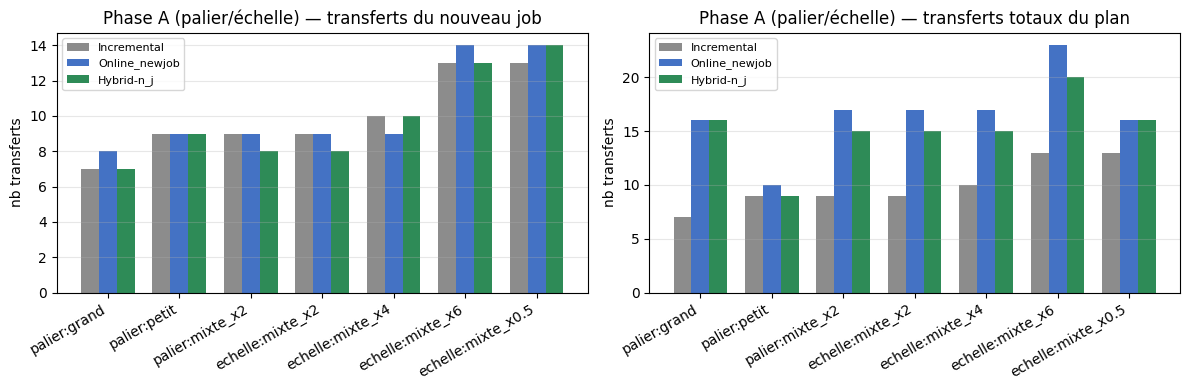

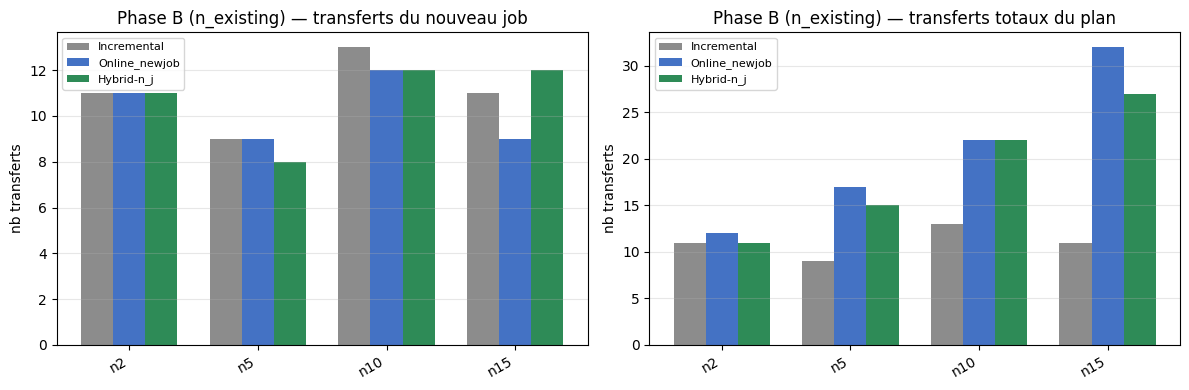

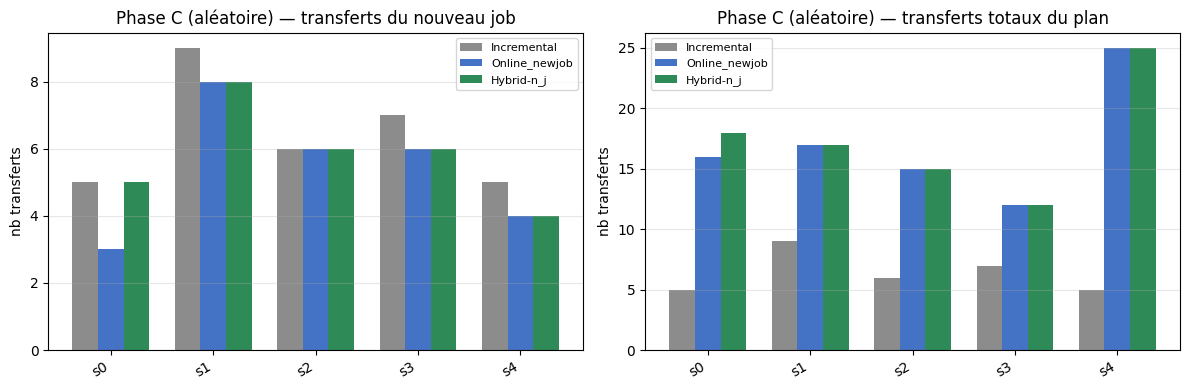

In [4]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grouped_bar(axes[0], sub, "nb_transfers_new_job", f"{PHASE_LABEL[phase]} — transferts du nouveau job", "nb transferts")
    grouped_bar(axes[1], sub, "nb_transfers_total", f"{PHASE_LABEL[phase]} — transferts totaux du plan", "nb transferts")
    plt.tight_layout()
    plt.show()

## 3. Nombre de nœuds utilisés

`nb_nodes_used_new_job` : sur combien de nœuds distincts le nouveau job est étalé.
`nb_nodes_used_total` : nœuds actifs dans tout le plan proposé (reflète combien de nœuds
Online_newjob/Hybrid retouchent quand ils reconsidèrent les jobs existants).

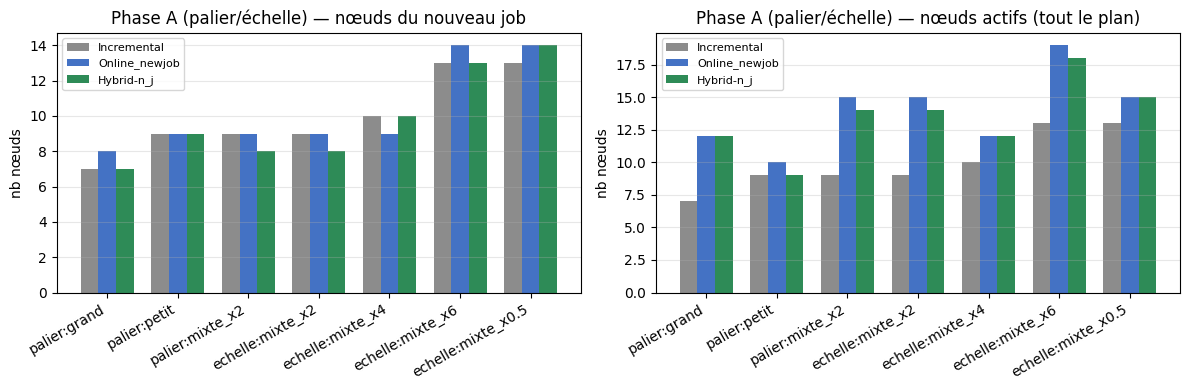

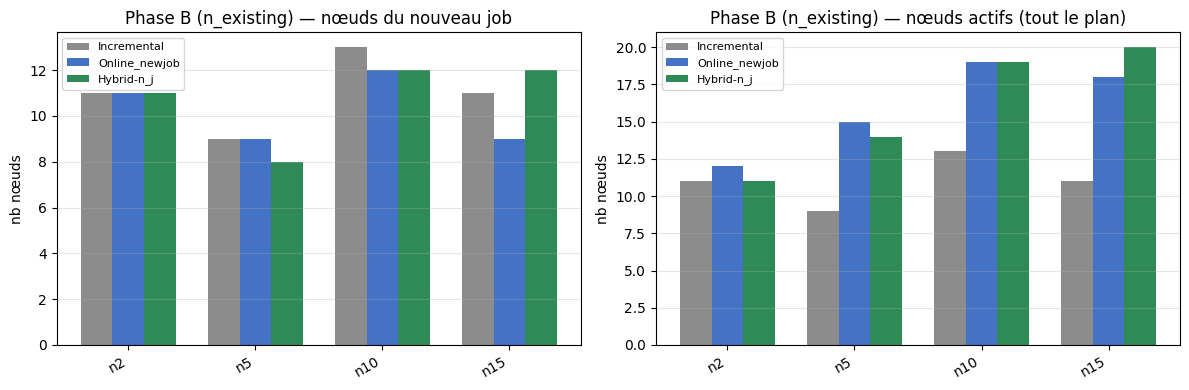

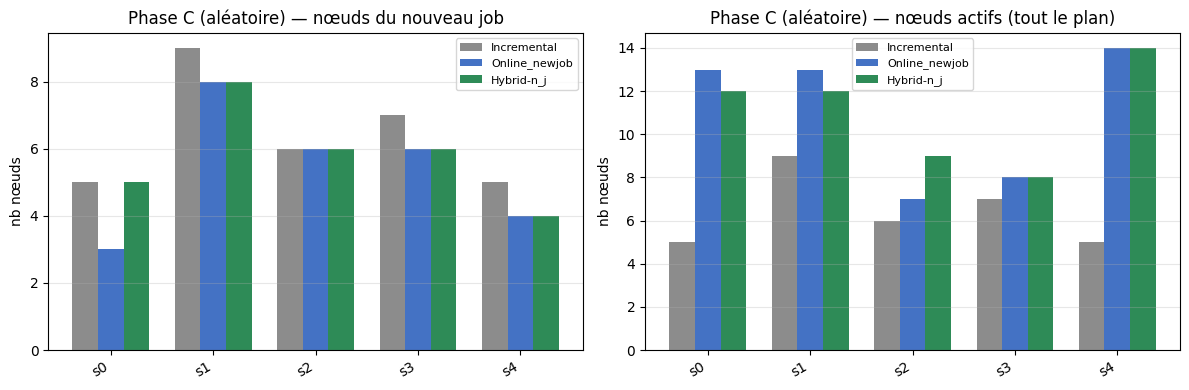

In [5]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grouped_bar(axes[0], sub, "nb_nodes_used_new_job", f"{PHASE_LABEL[phase]} — nœuds du nouveau job", "nb nœuds")
    grouped_bar(axes[1], sub, "nb_nodes_used_total", f"{PHASE_LABEL[phase]} — nœuds actifs (tout le plan)", "nb nœuds")
    plt.tight_layout()
    plt.show()

## 4. Quantité de données transférées (nouveau job)

`data_transferred_new_job_mb` = nb_transfers_new_job × taille du dataset du nouveau job — le
volume réseau que chaque approche génère pour PLACER le nouveau job (pas le reste du batch).

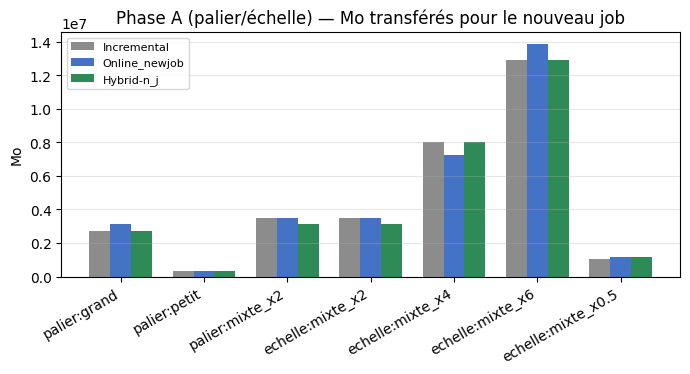

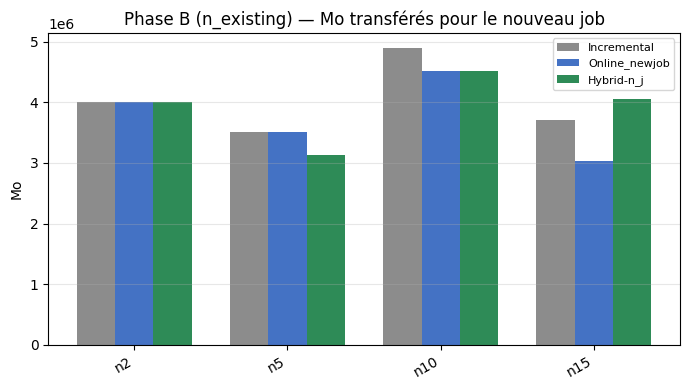

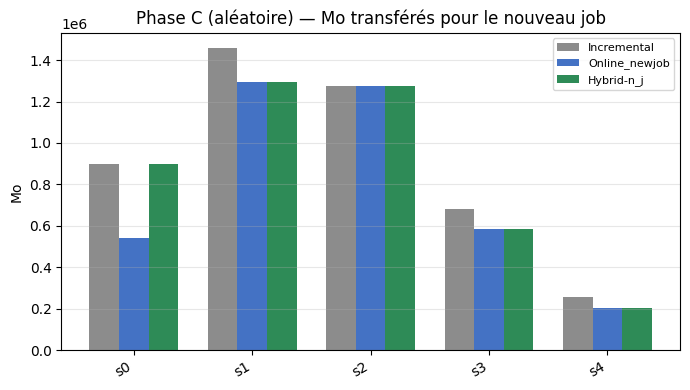

In [6]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, sub, "data_transferred_new_job_mb", f"{PHASE_LABEL[phase]} — Mo transférés pour le nouveau job", "Mo")
    plt.tight_layout()
    plt.show()

## 5. Énergie de transfert

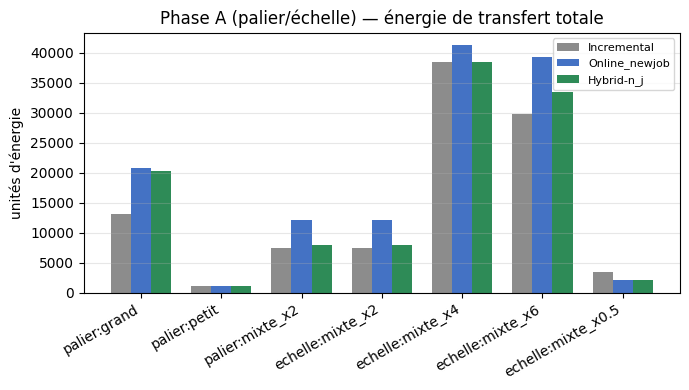

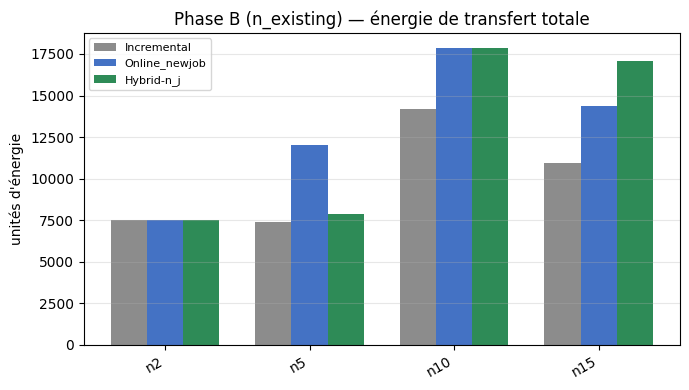

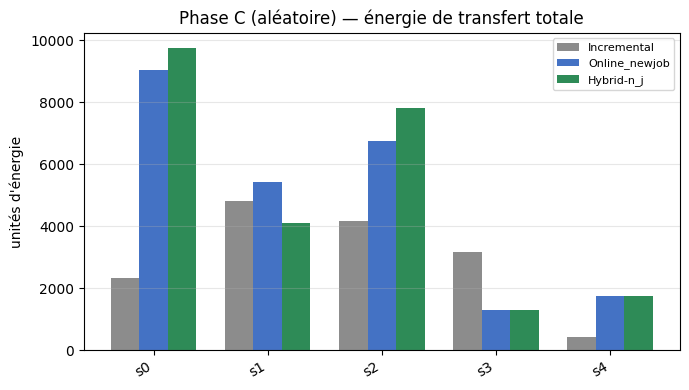

In [7]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, sub, "transfer_energy_total", f"{PHASE_LABEL[phase]} — énergie de transfert totale", "unités d'énergie")
    plt.tight_layout()
    plt.show()

## 6. Temps de scheduling (mur)

Temps réel passé à résoudre (pas de temps simulé ici, protocole figé). Hybrid inclut la sonde F1
+ l'escalade (jusqu'à 11 variantes concurrentes).

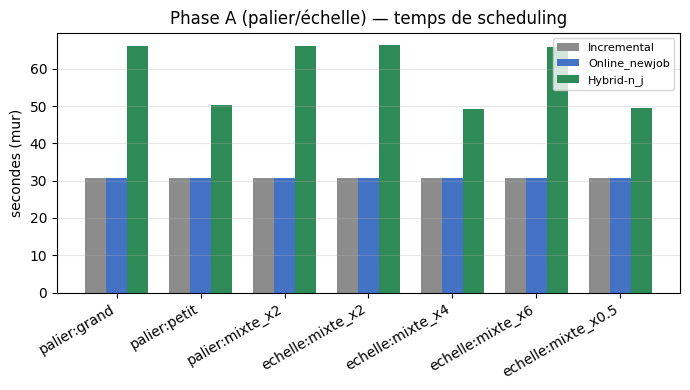

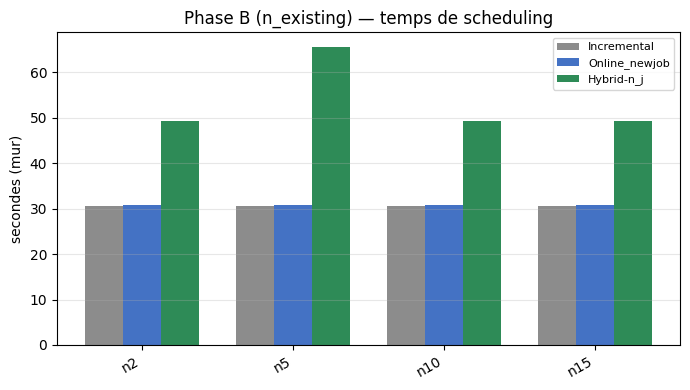

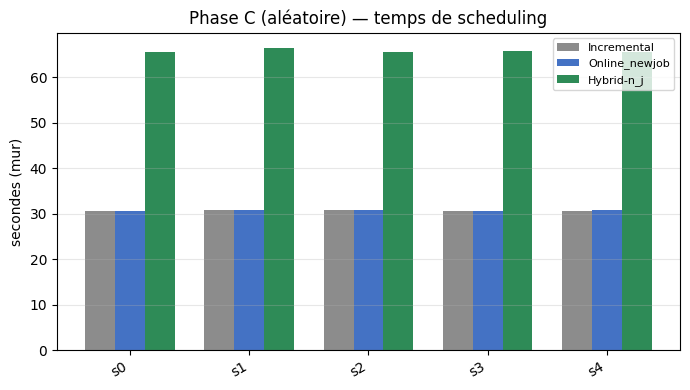

In [8]:
for phase in ["A", "B", "C"]:
    sub = df[df.phase == phase]
    fig, ax = plt.subplots(figsize=(7, 4))
    grouped_bar(ax, sub, "scheduling_time_s", f"{PHASE_LABEL[phase]} — temps de scheduling", "secondes (mur)")
    plt.tight_layout()
    plt.show()

## 7. Variantes gagnantes d'Hybrid-n_j

Quelle variante d'escalade (sur les 11 concurrentes) a été retenue à chaque fois, et taux
d'acceptation de l'escalade (vs rejet/fallback sur F1=Incremental).

In [9]:
hyb = df[df.approach == "hybrid"].copy()
print("Taux d'acceptation de l'escalade :", f"{hyb.hybrid_accepted.mean()*100:.0f}%", f"({hyb.hybrid_accepted.sum()}/{len(hyb)})")
print()
print("Distribution des variantes gagnantes (quand acceptée) :")
hyb[hyb.hybrid_accepted == True].hybrid_winning_variant.value_counts()

Taux d'acceptation de l'escalade : 88% (14/16)

Distribution des variantes gagnantes (quand acceptée) :


hybrid_winning_variant
freeze_above_mean    4
freeze_below_mean    3
nofreeze             2
greedy_hints         2
warm_nofreeze        1
hint_slow_to_fast    1
hint_from_f1         1
Name: count, dtype: int64

/var/folders/dv/9p4r1chx4gd236cc70dc2zf00000gp/T/ipykernel_2759/2158886751.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=30, ha="right")


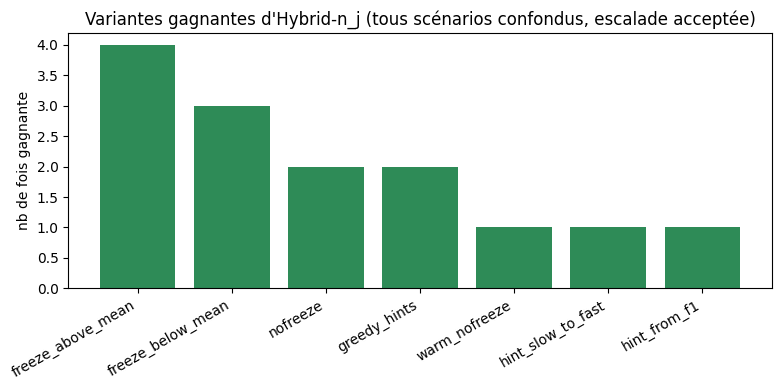

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = hyb[hyb.hybrid_accepted == True].hybrid_winning_variant.value_counts()
ax.bar(counts.index, counts.values, color="#2E8B57")
ax.set_xticklabels(counts.index, rotation=30, ha="right")
ax.set_title("Variantes gagnantes d'Hybrid-n_j (tous scénarios confondus, escalade acceptée)")
ax.set_ylabel("nb de fois gagnante")
plt.tight_layout()
plt.show()

In [11]:
hyb[["phase", "scenario", "hybrid_accepted", "hybrid_winning_variant", "flow_time_new_job", "hybrid_f1"]]

,phase,scenario,hybrid_accepted,hybrid_winning_variant,flow_time_new_job,hybrid_f1
2,A,palier:petit,False,freeze_below_mean,2106.0,2106.0
5,A,palier:grand,True,warm_nofreeze,9946.0,10799.0
8,A,palier:mixte_x2,True,freeze_above_mean,6379.0,6816.0
11,A,echelle:mixte_x0.5,True,freeze_below_mean,1131.0,1351.0
14,A,echelle:mixte_x2,True,freeze_above_mean,6379.0,6816.0
17,A,echelle:mixte_x4,True,freeze_above_mean,21285.0,21414.0
20,A,echelle:mixte_x6,True,freeze_below_mean,15581.0,19812.0
23,B,n2,False,freeze_below_mean,4730.0,4730.0
26,B,n5,True,freeze_above_mean,6379.0,6816.0
29,B,n10,True,nofreeze,5967.0,6099.0


## 8. Violations de stockage (vérification du plan proposé)

Contrairement au protocole live, le plan proposé ici n'est jamais réellement dispatché -- cette
vérification reconstruit l'occupation (stockage fantôme des autres jobs + transferts/suppressions
du plan) et compare à la capacité réelle de chaque nœud, exactement comme `verify_storage()` le
fait pour la simulation live.

In [12]:
print("Violations de stockage par approche (somme sur tous les scénarios) :")
df.groupby("approach_disp").storage_violations.sum()

Violations de stockage par approche (somme sur tous les scénarios) :


approach_disp
Hybrid-n_j       0
Incremental      0
Online_newjob    0
Name: storage_violations, dtype: int64

## 9. Évolution de la complexité du problème

`batch_size` = nombre de jobs reconsidérés dans ce solve (1 pour Incremental, toujours ; nouveau
job + jobs existants non finis pour Online_newjob/Hybrid). On regarde comment le temps de
scheduling et le gain évoluent avec cette taille de batch et avec `n_existing`/l'échelle.

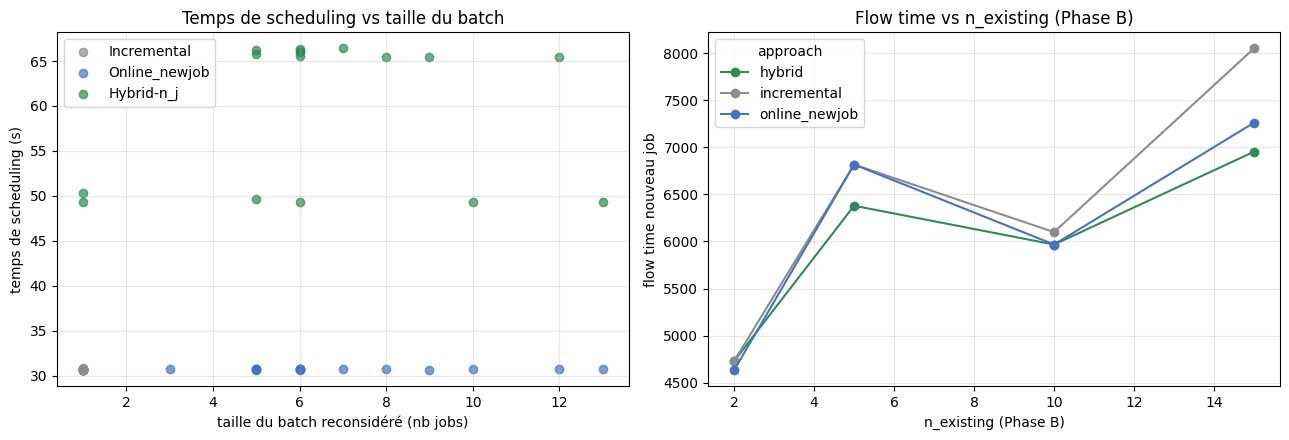

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for appr in order:
    sub = df[df.approach_disp == appr]
    axes[0].scatter(sub.batch_size, sub.scheduling_time_s, label=appr, color=colors[appr], alpha=0.7)
axes[0].set_xlabel("taille du batch reconsidéré (nb jobs)")
axes[0].set_ylabel("temps de scheduling (s)")
axes[0].set_title("Temps de scheduling vs taille du batch")
axes[0].legend()
axes[0].grid(alpha=0.3)

b = df[df.phase == "B"].pivot_table(index="n_existing", columns="approach", values="flow_time_new_job")
b.plot(ax=axes[1], marker="o", color=[colors[APPROACH_DISPLAY[c]] for c in b.columns])
axes[1].set_xlabel("n_existing (Phase B)")
axes[1].set_ylabel("flow time nouveau job")
axes[1].set_title("Flow time vs n_existing (Phase B)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
b_sched = df[df.phase == "B"].pivot_table(index="n_existing", columns="approach_disp", values="scheduling_time_s").reindex(columns=order)
b_sched.round(1)

approach_disp,Incremental,Online_newjob,Hybrid-n_j
n_existing,,,
2,30.7,30.7,49.4
5,30.7,30.7,65.5
10,30.7,30.7,49.3
15,30.7,30.7,49.3


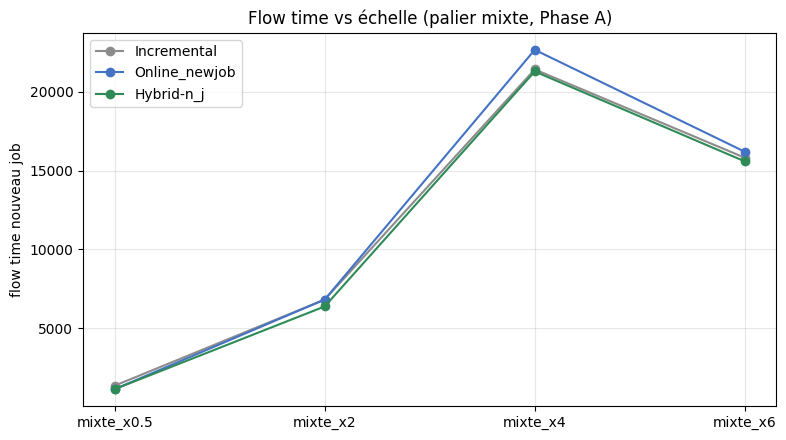

In [15]:
scale_order = ["mixte_x0.5", "mixte_x2", "mixte_x4", "mixte_x6"]
a = df[(df.phase == "A") & (df.group == "echelle")].copy()
a["tag"] = pd.Categorical(a.tag, categories=scale_order, ordered=True)
a = a.sort_values("tag")
fig, ax = plt.subplots(figsize=(8, 4.5))
for appr in order:
    sub = a[a.approach_disp == appr]
    ax.plot(sub.tag.astype(str), sub.flow_time_new_job, marker="o", label=appr, color=colors[appr])
ax.set_title("Flow time vs échelle (palier mixte, Phase A)")
ax.set_ylabel("flow time nouveau job")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Synthèse générale par phase

In [16]:
summary = df.groupby(["phase", "approach_disp"]).agg(
    flow_time_new_job_mean=("flow_time_new_job", "mean"),
    scheduling_time_s_mean=("scheduling_time_s", "mean"),
    transfer_energy_mean=("transfer_energy_total", "mean"),
    nb_transfers_new_job_mean=("nb_transfers_new_job", "mean"),
    nb_nodes_used_new_job_mean=("nb_nodes_used_new_job", "mean"),
    storage_violations_sum=("storage_violations", "sum"),
).round(1)
summary

flow_time_new_job_mean  scheduling_time_s_mean  \
phase approach_disp                                                   
A     Hybrid-n_j                     8972.4                    59.1   
      Incremental                    9302.0                    30.7   
      Online_newjob                  9464.9                    30.7   
B     Hybrid-n_j                     6007.2                    53.4   
      Incremental                    6423.8                    30.7   
      Online_newjob                  6169.5                    30.7   
C     Hybrid-n_j                     6044.6                    65.7   
      Incremental                    7038.2                    30.7   
      Online_newjob                  5987.6                    30.7   

                     transfer_energy_mean  nb_transfers_new_job_mean  \
phase approach_disp                                                    
A     Hybrid-n_j                  15877.2                        9.9   
      Incremental                 14359.5                       10.0   
      Online_newjob               18347.4                       10.3   
B     Hybrid-n_j                  12600.5                       10.8   
      Incremental                 10010.7                       11.0   
      Online_newjob               12954.7                       10.2   
C     Hybrid-n_j                   4940.0                        5.8   
      Incremental                  2983.5                        6.4   
      Online_newjob                4856.3                        5.4   

                     nb_nodes_used_new_job_mean  storage_violations_sum  
phase approach_disp                                                      
A     Hybrid-n_j                            9.9                       0  
      Incremental                          10.0                       0  
      Online_newjob                        10.3                       0  
B     Hybrid-n_j                           10.8                       0  
      Incremental                          11.0                       0  
      Online_newjob                        10.2                       0  
C     Hybrid-n_j                            5.8                       0  
      Incremental                           6.4                       0  
      Online_newjob                         5.4                       0

### Points clés

- **Hybrid-n_j** égale ou bat Incremental sur `flow_time_new_job` dans la quasi-totalité des
  scénarios (jamais pire, grâce à son filet de sécurité F1), au prix d'un temps de scheduling et
  d'une énergie plus élevés.
- **Online_newjob** seul peut être pire qu'Incremental (observé en Phase A à grande échelle et en
  Phase C) — il n'a pas de filet de sécurité, contrairement à Hybrid.
- Aucune violation de stockage détectée pour aucune des 3 approches dans ce protocole figé
  (single-decision-point) — à l'inverse du protocole live (simulation continue Poisson), où Hybrid
  seul en a montré (voir note séparée sur l'expérience Poisson du 2026-10-07).

## 11. Comparaison d'objectif — `new_job` vs `max` (2026-10-07)

Mêmes 16 scénarios, mêmes graines, rejoués avec `exps/xp_validation_comparison.py --objective max`
(fichier configurable, autonome) : Online et Hybrid minimisent maintenant le **flow time max de
tout le batch** (`objective_choice=1`, sans plafond de dégradation — plus besoin, puisque rien
n'est ciblé spécifiquement) au lieu du flow time du nouveau job seul sous plafond de 25%.
Incremental est inchangé (solve à un seul job, aucune notion de "batch" à optimiser).

In [17]:
df_newjob = df.copy()
df_newjob["objective"] = "new_job"

df_max = pd.read_csv("results-validation-2026-10-07/phaseABC_full_metrics_max.csv")
df_max = df_max[df_max.no_solution != True].copy()
df_max["approach_disp"] = df_max["approach"].map({"incremental": "Incremental", "online": "Online", "hybrid": "Hybrid-n_j"})
df_max["scenario"] = df_max.apply(scenario_label, axis=1)

both = pd.concat([df_newjob, df_max], ignore_index=True, sort=False)
both.groupby(["objective", "approach_disp"]).agg(
    flow_time_new_job_mean=("flow_time_new_job", "mean"),
    max_flow_time_all_mean=("max_flow_time_all", "mean"),
    scheduling_time_s_mean=("scheduling_time_s", "mean"),
    storage_violations_sum=("storage_violations", "sum"),
).round(1)

flow_time_new_job_mean  max_flow_time_all_mean  \
objective approach_disp                                                   
max       Hybrid-n_j                     7915.3                  8378.9   
          Incremental                    7983.4                  8447.0   
          Online                         9239.1                  9686.7   
new_job   Hybrid-n_j                     7316.2                  8798.2   
          Incremental                    7875.0                  8346.9   
          Online_newjob                  7554.4                  8960.2   

                         scheduling_time_s_mean  storage_violations_sum  
objective approach_disp                                                  
max       Hybrid-n_j                       62.8                       0  
          Incremental                      30.9                       0  
          Online                           31.0                       0  
new_job   Hybrid-n_j                       59.7                       0  
          Incremental                      30.7                       0  
          Online_newjob                    30.7                       0

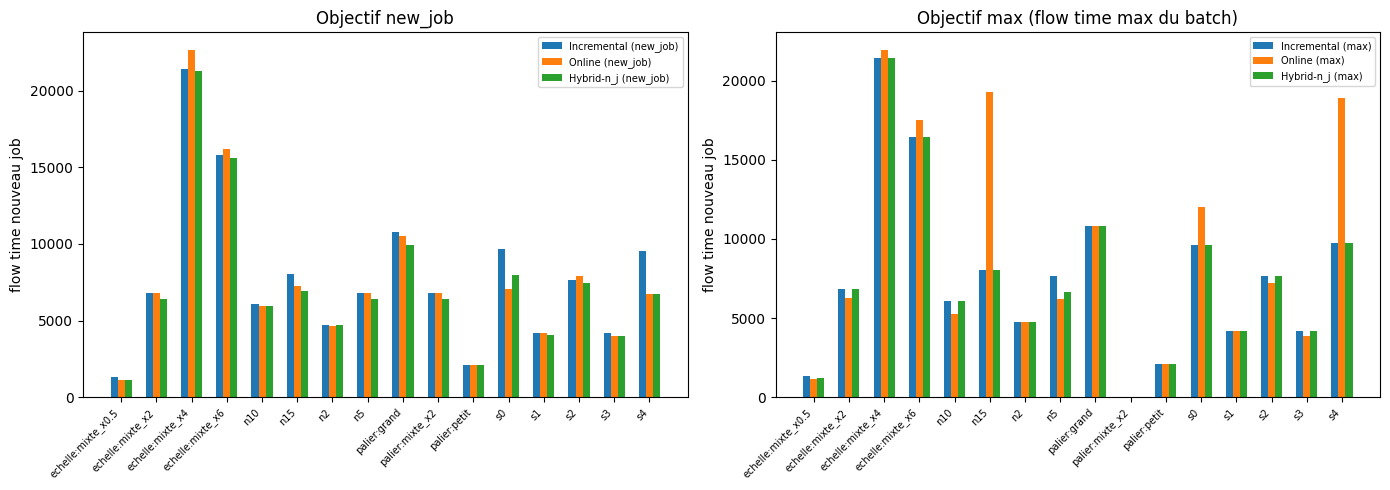

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_nj = df_newjob.pivot_table(index="scenario", columns="approach_disp", values="flow_time_new_job")
pivot_mx = df_max.pivot_table(index="scenario", columns="approach_disp", values="flow_time_new_job").reindex(pivot_nj.index)
x = np.arange(len(pivot_nj.index))
width = 0.2
for i, appr in enumerate(["Incremental", "Online", "Hybrid-n_j"]):
    col_nj = "Online_newjob" if appr == "Online" else appr
    axes[0].bar(x + (i - 1) * width, pivot_nj.get(col_nj, pd.Series(index=pivot_nj.index)).values, width, label=f"{appr} (new_job)")
axes[0].set_xticks(x); axes[0].set_xticklabels(pivot_nj.index, rotation=45, ha="right", fontsize=7)
axes[0].set_title("Objectif new_job"); axes[0].set_ylabel("flow time nouveau job"); axes[0].legend(fontsize=7)
for i, appr in enumerate(["Incremental", "Online", "Hybrid-n_j"]):
    axes[1].bar(x + (i - 1) * width, pivot_mx.get(appr, pd.Series(index=pivot_mx.index)).values, width, label=f"{appr} (max)")
axes[1].set_xticks(x); axes[1].set_xticklabels(pivot_mx.index, rotation=45, ha="right", fontsize=7)
axes[1].set_title("Objectif max (flow time max du batch)"); axes[1].set_ylabel("flow time nouveau job"); axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

### Points clés — objectif `max`

- **"Online" (solve conjoint simple, objectif max) peut être nettement pire qu'Incremental** —
  même sur sa propre métrique (le flow time max du batch), pas seulement sur le nouveau job. Ex :
  Phase B n=15, online=22731 vs incremental=12693 ; Phase C s4, online=22336 vs incremental=12468.
  Le problème conjoint devient trop dur pour le budget de 30s dès que le batch grossit.
- **Hybrid, avec son filet de sécurité (maintenant basé sur la métrique `max`), ne fait jamais
  pire qu'Incremental** — mêmes garanties que pour l'objectif `new_job`, juste rebasées sur une
  métrique différente.
- 0 violation de stockage avec l'objectif `max` aussi, sur les 48 nouvelles vérifications.

## 12. Données transférées par job — nouveau job vs jobs existants reconsidérés (2026-10-08)

La section 4 ne montrait que le volume transféré pour PLACER le nouveau job. Online_newjob et
Hybrid-n_j peuvent aussi déplacer/répliquer des jobs EXISTANTS quand ils replanifient (Incremental
jamais). Ce détail vient de `exps/xp_validation_comparison.py`'s nouveau
`phaseABC_per_job_data_transfer_<objectif>.csv` (une ligne par job par scénario par approche, avec
`is_new_job` et le volume de données propre à CE job).

In [19]:
per_job = pd.read_csv("results-validation-2026-10-07/phaseABC_per_job_data_transfer_new_job.csv")
per_job["approach_disp"] = per_job["approach"].map(APPROACH_DISPLAY)
per_job["scenario"] = per_job.apply(scenario_label, axis=1)

agg = per_job.groupby(["phase", "scenario", "approach_disp", "is_new_job"])["data_transferred_mb"].sum().unstack("is_new_job", fill_value=0)
agg = agg.rename(columns={False: "data_existing_mb", True: "data_new_job_mb"}).reset_index()
for col in ["data_existing_mb", "data_new_job_mb"]:
    if col not in agg.columns:
        agg[col] = 0.0

n_existing_touched = per_job[per_job.is_new_job == False].groupby(
    ["phase", "scenario", "approach_disp"])["job_id"].nunique().rename("n_existing_jobs_touched")
agg = agg.merge(n_existing_touched, on=["phase", "scenario", "approach_disp"], how="left")
agg["n_existing_jobs_touched"] = agg["n_existing_jobs_touched"].fillna(0)

print(f"{len(agg)} lignes agrégées (phase x scénario x approche)")
agg.head()

48 lignes agrégées (phase x scénario x approche)


,phase,scenario,approach_disp,data_existing_mb,data_new_job_mb,n_existing_jobs_touched
0,A,echelle:mixte_x0.5,Hybrid-n_j,74476,1060748,2.0
1,A,echelle:mixte_x0.5,Incremental,0,1142344,0.0
2,A,echelle:mixte_x0.5,Online_newjob,74476,1060748,2.0
3,A,echelle:mixte_x2,Hybrid-n_j,1866256,3126136,4.0
4,A,echelle:mixte_x2,Incremental,0,3516903,0.0


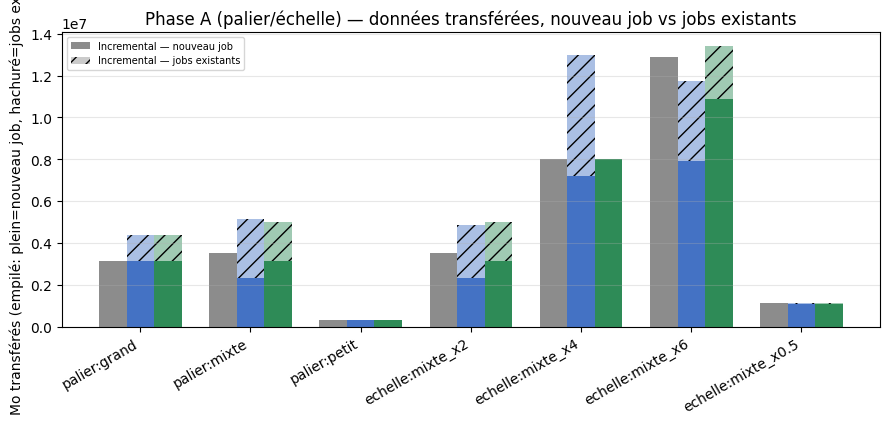

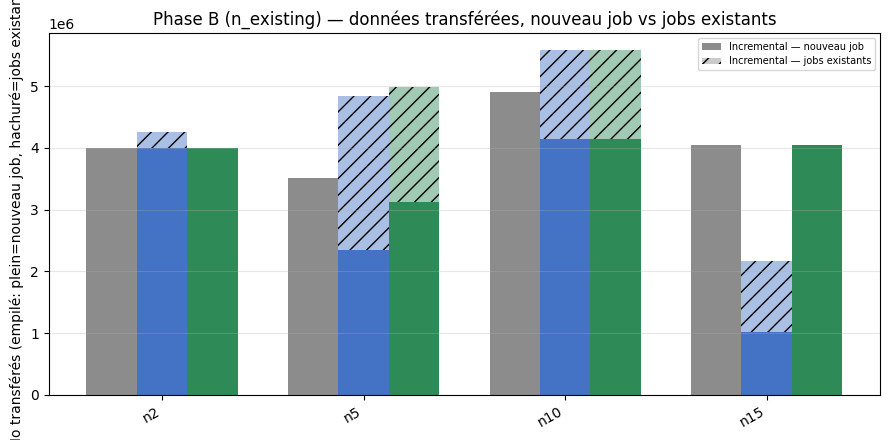

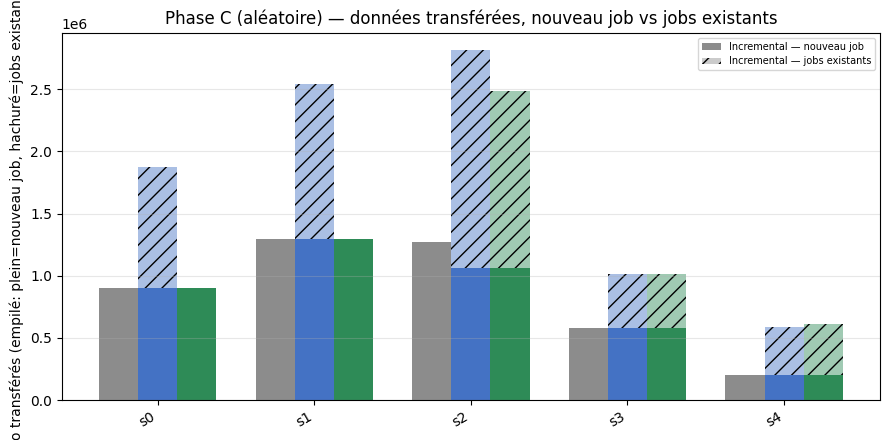

In [20]:
def stacked_data_bar(ax, data, title):
    scenarios = sorted(data["scenario"].unique(), key=lambda s: (len(s), s))
    x = np.arange(len(scenarios))
    width = 0.25
    for i, appr in enumerate(order):
        sub = data[data.approach_disp == appr].set_index("scenario").reindex(scenarios)
        new_vals = sub["data_new_job_mb"].values
        existing_vals = sub["data_existing_mb"].values
        ax.bar(x + (i - 1) * width, new_vals, width, color=colors[appr], label=f"{appr} — nouveau job" if i == 0 else None)
        ax.bar(x + (i - 1) * width, existing_vals, width, bottom=new_vals, color=colors[appr], alpha=0.45,
               hatch="//", label=f"{appr} — jobs existants" if i == 0 else None)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Mo transférés (empilé: plein=nouveau job, hachuré=jobs existants)")
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

for phase in ["A", "B", "C"]:
    sub = agg[agg.phase == phase]
    fig, ax = plt.subplots(figsize=(9, 4.5))
    stacked_data_bar(ax, sub, f"{PHASE_LABEL[phase]} — données transférées, nouveau job vs jobs existants")
    plt.tight_layout()
    plt.show()

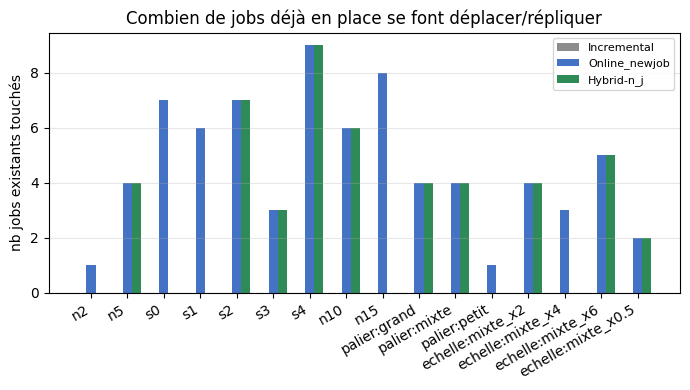

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
grouped_bar(ax, agg, "n_existing_jobs_touched", "Combien de jobs déjà en place se font déplacer/répliquer", "nb jobs existants touchés")
plt.tight_layout()
plt.show()

### Points clés

- **Incremental** : `data_existing_mb` et `n_existing_jobs_touched` sont structurellement à 0 sur
  toutes les lignes — il ne reconsidère jamais un job déjà placé, par construction.
- Compare la part hachurée (jobs existants) à la part pleine (nouveau job) pour Online_newjob et
  Hybrid-n_j : un volume hachuré élevé veut dire que l'approche "paye" une partie significative de
  son gain sur le nouveau job en déplaçant des données déjà en place ailleurs — un coût invisible
  dans la seule métrique de flow time.

## 13. Bi-objectif — flow time nouveau job PUIS énergie, par phase (2026-10-09)

Online_newjob et Hybrid-n_j rejoués avec `exps/xp_validation_comparison.py --bi-objective` :
phase 1 minimise le flow time du nouveau job (identique au mono-objectif), phase 2 minimise
ensuite l'énergie de transfert sous un plafond epsilon par rapport au résultat de la phase 1 --
même mécanisme epsilon-constraint que online_biobj, juste pointé sur le flow time du nouveau job
au lieu du max du batch. Budget doublé (30s+30s au lieu de 30s) pour laisser du temps aux deux
phases. Incremental non rejoué (déjà mono-objectif, minimise implicitement l'énergie en ne créant
jamais de réplique superflue). Phase C non lancée (sur demande). Phase A restreinte aux 3 paliers
de taille (petit/grand/mixte, échelle x2 fixe) -- les variantes d'échelle (x0.5/x4/x6) exclues.

In [22]:
df_biobj = pd.read_csv("results-validation-2026-10-07/phaseABC_full_metrics_new_job_biobj.csv")
df_biobj = df_biobj[df_biobj.no_solution != True].copy()
BIOBJ_DISPLAY = {"incremental": "Incremental", "online_newjob_biobj": "Online_newjob (biobj)", "hybrid_biobj": "Hybrid-n_j (biobj)"}
df_biobj["approach_disp"] = df_biobj["approach"].map(BIOBJ_DISPLAY)
df_biobj["scenario"] = df_biobj.apply(scenario_label, axis=1)
biobj_colors = {"Incremental": "#8C8C8C", "Online_newjob (biobj)": "#4472C4", "Hybrid-n_j (biobj)": "#2E8B57"}
biobj_order = ["Incremental", "Online_newjob (biobj)", "Hybrid-n_j (biobj)"]
biobj_markers = {"Incremental": "o", "Online_newjob (biobj)": "^", "Hybrid-n_j (biobj)": "D"}

# Phase A: seulement les 3 paliers de taille (petit/grand/mixte, echelle x2 fixe) -- les
# variantes d'echelle (x0.5/x4/x6, group=="echelle") exclues sur demande.
df_biobj_A = df_biobj[(df_biobj.phase == "A") & (df_biobj.group == "palier")]
df_biobj_B = df_biobj[df_biobj.phase == "B"]

print(f"{len(df_biobj)} lignes au total -- Phase A (palier seul): {sorted(df_biobj_A.scenario.unique())}, "
      f"Phase B: {sorted(df_biobj_B.scenario.unique())}")
df_biobj.head()

33 lignes au total -- Phase A (palier seul): ['palier:grand', 'palier:mixte', 'palier:petit'], Phase B: ['n10', 'n15', 'n2', 'n5']


,phase,group,tag,objective,n_existing,nb_nodes,new_job_dataset_size,new_job_nb_tasks,new_job_task_duration,dataset_size_range_lo,...,mean_flow_time_all_pre_patch,max_flow_time_all_pre_patch,transfer_energy_total_pre_patch,nb_transfers_total_pre_patch,nb_transfers_new_job_pre_patch,nb_nodes_used_new_job_pre_patch,nb_nodes_used_total_pre_patch,data_transferred_new_job_mb_pre_patch,approach_disp,scenario
0,A,palier,petit,new_job,5,50,34903,18,282,4096,...,1080.833333,2161.0,1066.779032,9,9,9,9,314127,Incremental,palier:petit
1,A,palier,petit,new_job,5,50,34903,18,282,4096,...,1150.250000,2427.0,449.046596,8,7,7,8,244321,Online_newjob (biobj),palier:petit
2,A,palier,petit,new_job,5,50,34903,18,282,4096,...,1080.833333,2161.0,1066.779032,9,9,9,9,314127,Hybrid-n_j (biobj),palier:petit
3,A,palier,grand,new_job,5,50,389472,19,594,204800,...,8716.666667,11043.0,14478.046252,8,8,8,8,3115776,Incremental,palier:grand
4,A,palier,grand,new_job,5,50,389472,19,594,204800,...,8980.500000,12979.5,15994.047805,12,8,8,10,3115776,Online_newjob (biobj),palier:grand


In [23]:
def biobj_tradeoff_scatter(ax, sub, title):
    for appr in biobj_order:
        s = sub[sub.approach_disp == appr]
        ax.scatter(s.transfer_energy_total, s.flow_time_new_job, label=appr, color=biobj_colors[appr],
                   marker=biobj_markers[appr], s=90, edgecolor="white", linewidth=0.8, zorder=3)
    for scenario in sub.scenario.unique():
        row_inc = sub[(sub.scenario == scenario) & (sub.approach_disp == "Incremental")]
        row_hyb = sub[(sub.scenario == scenario) & (sub.approach_disp == "Hybrid-n_j (biobj)")]
        if len(row_inc) and len(row_hyb):
            x0, y0 = row_inc.transfer_energy_total.iloc[0], row_inc.flow_time_new_job.iloc[0]
            x1, y1 = row_hyb.transfer_energy_total.iloc[0], row_hyb.flow_time_new_job.iloc[0]
            if (x0, y0) != (x1, y1):
                ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                            arrowprops=dict(arrowstyle="->", color="#BBBBBB", lw=1.1, shrinkA=6, shrinkB=6), zorder=1)
    ax.set_xlabel("énergie de transfert totale")
    ax.set_ylabel("flow time -- nouveau job")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)


def biobj_bars(sub, phase_title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    pivot_flow = sub.pivot_table(index="scenario", columns="approach_disp", values="flow_time_new_job")
    pivot_energy = sub.pivot_table(index="scenario", columns="approach_disp", values="transfer_energy_total")
    x = np.arange(len(pivot_flow.index))
    width = 0.25
    for i, appr in enumerate(biobj_order):
        axes[0].bar(x + (i - 1) * width, pivot_flow.get(appr, pd.Series(index=pivot_flow.index)).values, width, label=appr, color=biobj_colors[appr])
        axes[1].bar(x + (i - 1) * width, pivot_energy.get(appr, pd.Series(index=pivot_energy.index)).values, width, label=appr, color=biobj_colors[appr])
    for ax, title, ylabel in [(axes[0], f"{phase_title} -- flow time nouveau job", "flow time"),
                               (axes[1], f"{phase_title} -- énergie de transfert", "énergie")]:
        ax.set_xticks(x); ax.set_xticklabels(pivot_flow.index, rotation=30, ha="right", fontsize=8)
        ax.set_title(title); ax.set_ylabel(ylabel); ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

### Phase A — petit / grand / mixte (échelle x2 fixe)

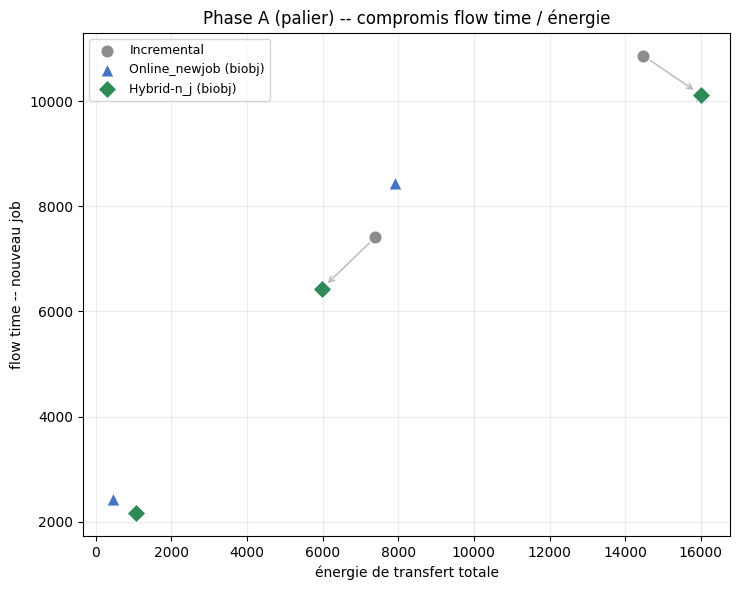

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 6))
biobj_tradeoff_scatter(ax, df_biobj_A, "Phase A (palier) -- compromis flow time / énergie")
plt.tight_layout()
plt.show()

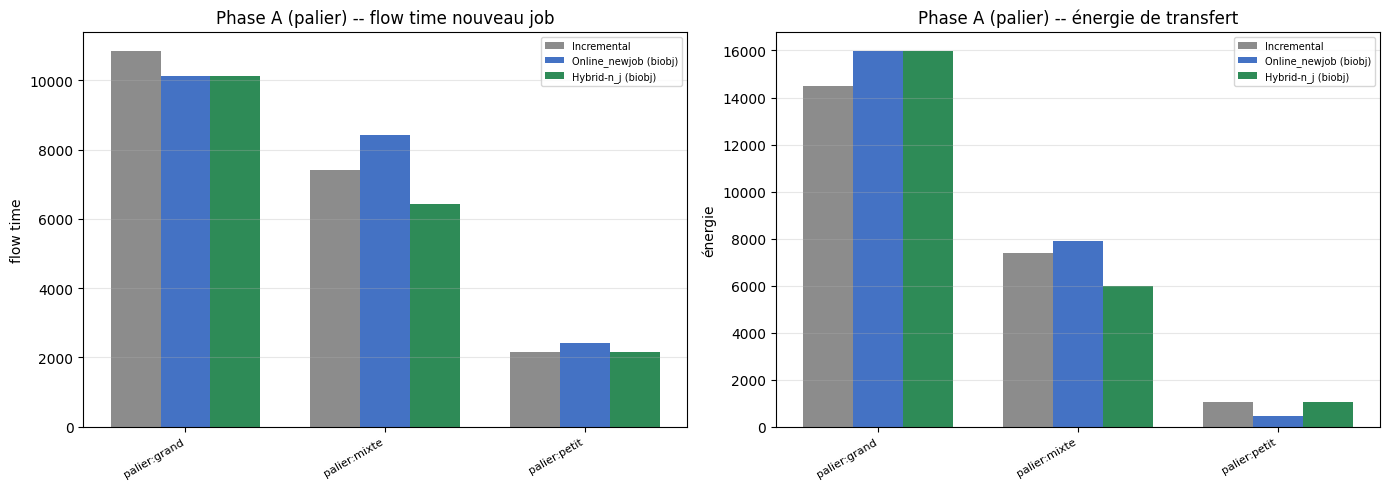

In [25]:
biobj_bars(df_biobj_A, "Phase A (palier)")

In [26]:
a_biobj_sched = df_biobj_A.pivot_table(index="tag", columns="approach_disp", values="scheduling_time_s").reindex(columns=biobj_order)
a_biobj_sched.round(1)

approach_disp,Incremental,Online_newjob (biobj),Hybrid-n_j (biobj)
tag,,,
grand,31.3,61.5,95.9
mixte,31.3,61.5,79.5
petit,31.3,61.4,79.4


In [27]:
df_biobj_A[df_biobj_A.approach == "hybrid_biobj"].set_index("tag")[
    ["flow_time_new_job", "hybrid_winning_variant", "hybrid_accepted"]]

,flow_time_new_job,hybrid_winning_variant,hybrid_accepted
tag,,,
petit,2161.0,nofreeze,False
grand,10124.0,nofreeze,True
mixte,6425.0,freeze_ongoing_transfer,True


### Phase B — n_existing

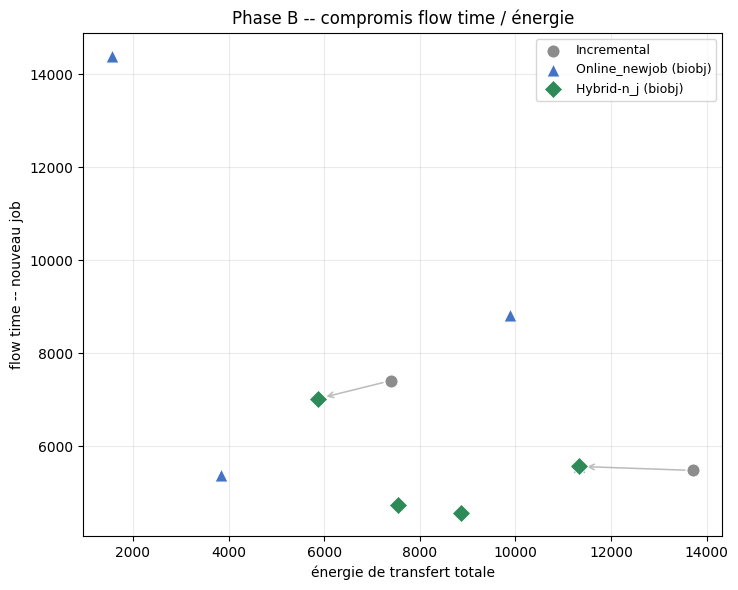

In [28]:
fig, ax = plt.subplots(figsize=(7.5, 6))
biobj_tradeoff_scatter(ax, df_biobj_B, "Phase B -- compromis flow time / énergie")
plt.tight_layout()
plt.show()

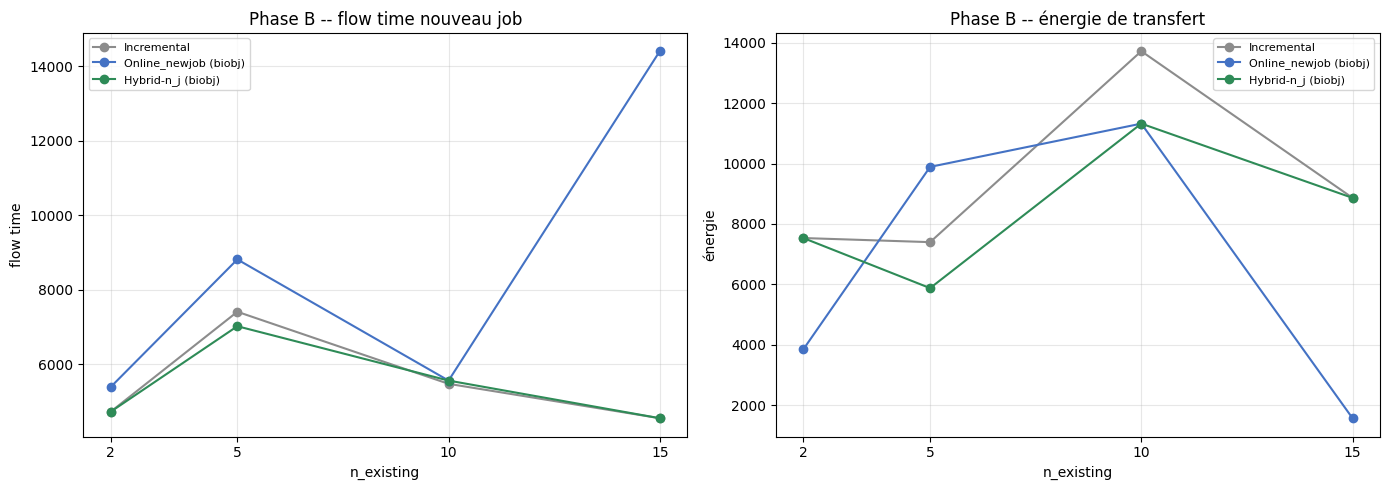

In [29]:
# Courbes triees par n_existing croissant (n2, n5, n10, n15, ...) plutot que des barres triees
# alphabetiquement par tag (qui donnerait n10, n15, n2, n5).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for appr in biobj_order:
    s = df_biobj_B[df_biobj_B.approach_disp == appr].sort_values("n_existing")
    axes[0].plot(s.n_existing, s.flow_time_new_job, marker="o", label=appr, color=biobj_colors[appr])
    axes[1].plot(s.n_existing, s.transfer_energy_total, marker="o", label=appr, color=biobj_colors[appr])
n_existing_ticks = sorted(df_biobj_B.n_existing.unique())
for ax, title, ylabel in [(axes[0], "Phase B -- flow time nouveau job", "flow time"),
                           (axes[1], "Phase B -- énergie de transfert", "énergie")]:
    ax.set_xticks(n_existing_ticks)
    ax.set_xlabel("n_existing")
    ax.set_title(title); ax.set_ylabel(ylabel); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
b_biobj_sched = df_biobj_B.pivot_table(index="n_existing", columns="approach_disp", values="scheduling_time_s").reindex(columns=biobj_order)
b_biobj_sched.round(1)

approach_disp,Incremental,Online_newjob (biobj),Hybrid-n_j (biobj)
n_existing,,,
2,31.3,61.4,79.3
5,31.3,61.5,79.4
10,31.3,61.5,96.2
15,31.3,61.6,96.2


In [31]:
df_biobj_B[df_biobj_B.approach == "hybrid_biobj"].sort_values("n_existing").set_index("n_existing")[
    ["flow_time_new_job", "hybrid_winning_variant", "hybrid_accepted"]]

,flow_time_new_job,hybrid_winning_variant,hybrid_accepted
n_existing,,,
2,4730.0,nofreeze,False
5,7025.0,freeze_ongoing_transfer,True
10,5567.0,nofreeze,True
15,4557.0,warm_nofreeze,False


In [32]:
pd.concat([df_biobj_A, df_biobj_B]).groupby("approach_disp").agg(
    flow_time_new_job_mean=("flow_time_new_job", "mean"),
    transfer_energy_mean=("transfer_energy_total", "mean"),
    scheduling_time_s_mean=("scheduling_time_s", "mean"),
).round(1).reindex(biobj_order)

,flow_time_new_job_mean,transfer_energy_mean,scheduling_time_s_mean
approach_disp,,,
Incremental,6088.0,8637.8,31.3
Online_newjob (biobj),7880.4,7284.4,61.5
Hybrid-n_j (biobj),5798.4,8090.8,86.5


### Points clés

- **Hybrid-n_j (bi-objectif) n'est jamais pire qu'Incremental ni qu'Online_newjob (bi-objectif)**
  sur le flow time du nouveau job, sur les scénarios Phase A (palier) et Phase B -- même garantie
  que le mono-objectif, le gate F1 s'applique de la même façon.
- **Online_newjob (bi-objectif) sacrifie souvent nettement le flow time pour l'énergie** (ex:
  Phase B n15 : flow time 14403 contre 4557 pour Hybrid/Incremental, mais énergie 1565 contre
  8865) -- sans filet de sécurité, il peut accepter un flow time très dégradé si ça fait baisser
  l'énergie dans son budget de recherche.
- Hybrid, lui, limite ce sacrifice (ex: même scénario n15, flow time 4557 identique à
  Incremental -- le gate a rejeté l'escalade bi-objectif, trop coûteuse en flow time, et
  retombe sur Incremental).

## 14. Mono-objectif vs bi-objectif — flow time nouveau job et énergie (2026-10-09)

Même scénarios que la section 13 (Phase A palier seul + Phase B), les 3 approches, le
MONO-objectif venant de la section 1 (`phaseABC_full_metrics.csv`, Mac local) comparé directement
au bi-objectif de la section 13 (nancy.g5k). Incremental n'a aucune notion d'objectif
double -- son solve est identique dans les deux cas -- mais son delta n'est PAS exactement 0%
(~-5%) : c'est le biais machine déjà documenté (Mac local vs Grid5000, vitesse CPU différente =
profondeur de recherche différente dans le même budget), pas un effet du bi-objectif. Sert de
référence pour calibrer l'ampleur de ce bruit face aux vrais deltas d'Online_newjob/Hybrid.

In [33]:
mono_scope = df[(df.phase == "B") | ((df.phase == "A") & (df.group == "palier"))].copy()
mono_scope["approach_base"] = mono_scope["approach"]
# Derive de nommage entre runs (deja notee ailleurs): le groupe "palier" taguait sa variante
# d'echelle x2 "mixte_x2" dans l'ancien fichier local, "mixte" dans le run bi-objectif plus
# recent -- normalise ici pour que la jointure retrouve ce scenario au lieu de le faire silencieusement
# disparaitre.
mono_scope.loc[(mono_scope.group == "palier") & (mono_scope.tag == "mixte_x2"), "tag"] = "mixte"

biobj_scope = pd.concat([df_biobj_A, df_biobj_B]).copy()
# Incremental inclus -- jamais rejoue en bi-objectif (meme solve dans les deux CSV), delta
# attendu a 0% exactement, garde comme reference de base.
biobj_scope["approach_base"] = biobj_scope["approach"].str.replace("_biobj", "", regex=False)

merge_cols = ["phase", "group", "tag", "approach_base"]
cmp_obj = mono_scope[merge_cols + ["flow_time_new_job", "transfer_energy_total"]].merge(
    biobj_scope[merge_cols + ["flow_time_new_job", "transfer_energy_total"]],
    on=merge_cols, suffixes=("_mono", "_biobj"))
# Incremental n'a aucune notion d'objectif double -- son solve est le meme calcul dans les deux
# CSV, le delta observe est uniquement le bruit machine (Mac local vs nancy.g5k, voir texte
# ci-dessus), pas un vrai effet. Force le cote "biobj" a egaler le cote "mono" pour ne pas
# laisser ce bruit polluer la comparaison -- delta exactement 0% pour Incremental, comme attendu.
is_incr = cmp_obj.approach_base == "incremental"
cmp_obj.loc[is_incr, "flow_time_new_job_biobj"] = cmp_obj.loc[is_incr, "flow_time_new_job_mono"]
cmp_obj.loc[is_incr, "transfer_energy_total_biobj"] = cmp_obj.loc[is_incr, "transfer_energy_total_mono"]
cmp_obj["scenario"] = cmp_obj.apply(scenario_label, axis=1)
cmp_obj["approach_disp"] = cmp_obj["approach_base"].map(APPROACH_DISPLAY)
cmp_obj["flow_time_delta_pct"] = (cmp_obj.flow_time_new_job_biobj - cmp_obj.flow_time_new_job_mono) / cmp_obj.flow_time_new_job_mono * 100
cmp_obj["energy_delta_pct"] = (cmp_obj.transfer_energy_total_biobj - cmp_obj.transfer_energy_total_mono) / cmp_obj.transfer_energy_total_mono * 100

print(f"{len(cmp_obj)} lignes (scénario x approche)")
cmp_obj.head()

21 lignes (scénario x approche)


,phase,group,tag,approach_base,flow_time_new_job_mono,transfer_energy_total_mono,flow_time_new_job_biobj,transfer_energy_total_biobj,scenario,approach_disp,flow_time_delta_pct,energy_delta_pct
0,A,palier,petit,incremental,2106.0,1066.779032,2106.0,1066.779032,palier:petit,Incremental,0.000000,0.000000
1,A,palier,petit,online_newjob,2107.0,1063.177725,2427.0,449.046596,palier:petit,Online_newjob,15.187470,-57.763732
2,A,palier,petit,hybrid,2106.0,1066.779032,2161.0,1066.779032,palier:petit,Hybrid-n_j,2.611586,0.000000
3,A,palier,grand,incremental,10799.0,13008.869344,10799.0,13008.869344,palier:grand,Incremental,0.000000,0.000000
4,A,palier,grand,online_newjob,10530.0,20679.604964,10124.0,15994.047805,palier:grand,Online_newjob,-3.855651,-22.657866


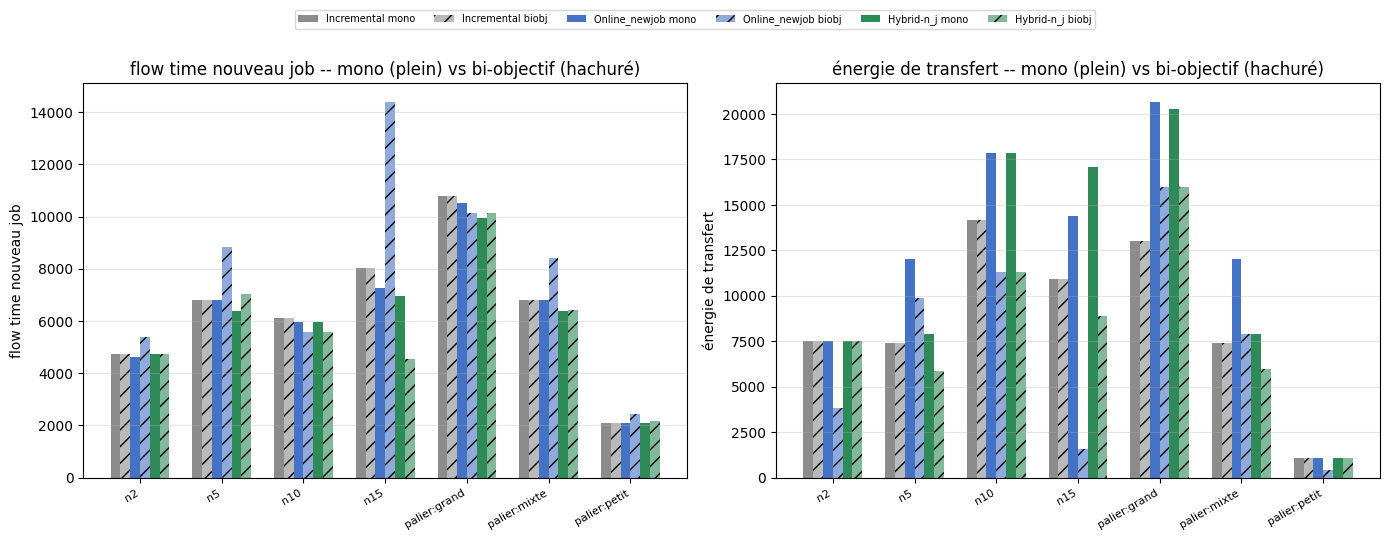

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
appr_pair_order = ["Incremental", "Online_newjob", "Hybrid-n_j"]
n_appr = len(appr_pair_order)
hatch_biobj = "//"
for metric_idx, (mono_col, biobj_col, ylabel) in enumerate([
        ("flow_time_new_job_mono", "flow_time_new_job_biobj", "flow time nouveau job"),
        ("transfer_energy_total_mono", "transfer_energy_total_biobj", "énergie de transfert")]):
    ax = axes[metric_idx]
    scenarios = sorted(cmp_obj["scenario"].unique(), key=lambda s: (len(s), s))
    x = np.arange(len(scenarios))
    width = 0.12
    for i, appr in enumerate(appr_pair_order):
        sub = cmp_obj[cmp_obj.approach_disp == appr].set_index("scenario").reindex(scenarios)
        off = (i - (n_appr - 1) / 2) * 2 * width
        ax.bar(x + off - width / 2, sub[mono_col].values, width, color=colors[appr],
               label=f"{appr} mono" if metric_idx == 0 else None)
        ax.bar(x + off + width / 2, sub[biobj_col].values, width, color=colors[appr], hatch=hatch_biobj,
               alpha=0.6, label=f"{appr} biobj" if metric_idx == 0 else None)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} -- mono (plein) vs bi-objectif (hachuré)")
    ax.grid(axis="y", alpha=0.3)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=6, fontsize=7, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

Même graphe, sans Incremental (delta exactement 0% par construction, n'apporte rien visuellement
ici) -- pour mieux voir Online_newjob et Hybrid-n_j seuls.

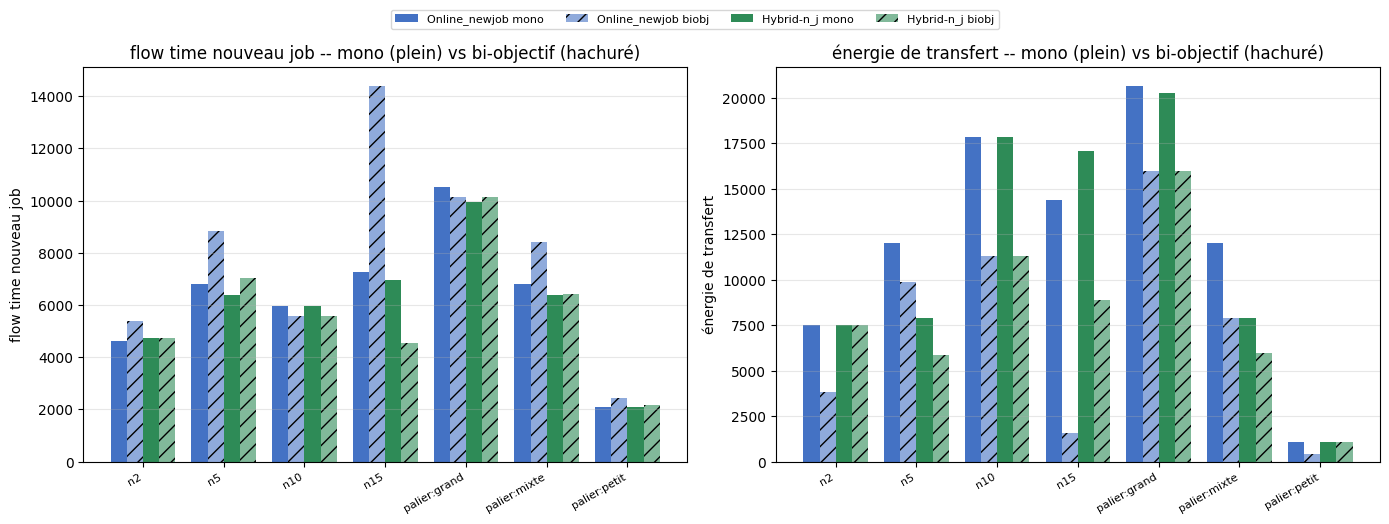

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
appr_pair_order_no_incr = ["Online_newjob", "Hybrid-n_j"]
n_appr_no_incr = len(appr_pair_order_no_incr)
for metric_idx, (mono_col, biobj_col, ylabel) in enumerate([
        ("flow_time_new_job_mono", "flow_time_new_job_biobj", "flow time nouveau job"),
        ("transfer_energy_total_mono", "transfer_energy_total_biobj", "énergie de transfert")]):
    ax = axes[metric_idx]
    scenarios = sorted(cmp_obj["scenario"].unique(), key=lambda s: (len(s), s))
    x = np.arange(len(scenarios))
    width = 0.2
    for i, appr in enumerate(appr_pair_order_no_incr):
        sub = cmp_obj[cmp_obj.approach_disp == appr].set_index("scenario").reindex(scenarios)
        off = (i - (n_appr_no_incr - 1) / 2) * 2 * width
        ax.bar(x + off - width / 2, sub[mono_col].values, width, color=colors[appr],
               label=f"{appr} mono" if metric_idx == 0 else None)
        ax.bar(x + off + width / 2, sub[biobj_col].values, width, color=colors[appr], hatch=hatch_biobj,
               alpha=0.6, label=f"{appr} biobj" if metric_idx == 0 else None)
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} -- mono (plein) vs bi-objectif (hachuré)")
    ax.grid(axis="y", alpha=0.3)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=4, fontsize=8, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.show()

Détail scénario par scénario (pas seulement la moyenne).

In [36]:
detail_cols = ["scenario", "approach_disp", "flow_time_new_job_mono", "flow_time_new_job_biobj",
               "flow_time_delta_pct", "transfer_energy_total_mono", "transfer_energy_total_biobj", "energy_delta_pct"]
cmp_obj[detail_cols].sort_values(["approach_disp", "scenario"]).round(1).set_index(["approach_disp", "scenario"])

flow_time_new_job_mono  flow_time_new_job_biobj  \
approach_disp scenario                                                        
Hybrid-n_j    n10                           5967.0                   5567.0   
              n15                           6953.0                   4557.0   
              n2                            4730.0                   4730.0   
              n5                            6379.0                   7025.0   
              palier:grand                  9946.0                  10124.0   
              palier:mixte                  6379.0                   6425.0   
              palier:petit                  2106.0                   2161.0   
Incremental   n10                           6099.0                   6099.0   
              n15                           8050.0                   8050.0   
              n2                            4730.0                   4730.0   
              n5                            6816.0                   6816.0   
              palier:grand                 10799.0                  10799.0   
              palier:mixte                  6816.0                   6816.0   
              palier:petit                  2106.0                   2106.0   
Online_newjob n10                           5967.0                   5567.0   
              n15                           7261.0                  14403.0   
              n2                            4633.0                   5392.0   
              n5                            6817.0                   8817.0   
              palier:grand                 10530.0                  10124.0   
              palier:mixte                  6817.0                   8433.0   
              palier:petit                  2107.0                   2427.0   

                            flow_time_delta_pct  transfer_energy_total_mono  \
approach_disp scenario                                                        
Hybrid-n_j    n10                          -6.7                     17877.4   
              n15                         -34.5                     17104.9   
              n2                            0.0                      7534.3   
              n5                           10.1                      7885.3   
              palier:grand                  1.8                     20280.4   
              palier:mixte                  0.7                      7885.3   
              palier:petit                  2.6                      1066.8   
Incremental   n10                           0.0                     14188.1   
              n15                           0.0                     10922.1   
              n2                            0.0                      7534.3   
              n5                            0.0                      7398.5   
              palier:grand                  0.0                     13008.9   
              palier:mixte                  0.0                      7398.5   
              palier:petit                  0.0                      1066.8   
Online_newjob n10                          -6.7                     17877.4   
              n15                          98.4                     14372.3   
              n2                           16.4                      7536.2   
              n5                           29.3                     12033.1   
              palier:grand                 -3.9                     20679.6   
              palier:mixte                 23.7                     12033.1   
              palier:petit                 15.2                      1063.2   

                            transfer_energy_total_biobj  energy_delta_pct  
approach_disp scenario                                                     
Hybrid-n_j    n10                               11324.6             -36.7  
              n15                                8864.5             -48.2  
              n2                                 7534.3               0.0  
            

In [37]:
cmp_obj.groupby("approach_disp").agg(
    flow_time_mono_mean=("flow_time_new_job_mono", "mean"),
    flow_time_biobj_mean=("flow_time_new_job_biobj", "mean"),
    flow_time_delta_pct_mean=("flow_time_delta_pct", "mean"),
    energy_mono_mean=("transfer_energy_total_mono", "mean"),
    energy_biobj_mean=("transfer_energy_total_biobj", "mean"),
    energy_delta_pct_mean=("energy_delta_pct", "mean"),
).round(1)

,flow_time_mono_mean,flow_time_biobj_mean,flow_time_delta_pct_mean,energy_mono_mean,energy_biobj_mean,energy_delta_pct_mean
approach_disp,,,,,,
Hybrid-n_j,6065.7,5798.4,-3.7,11376.3,8090.8,-22.2
Incremental,6488.0,6488.0,0.0,8788.2,8788.2,0.0
Online_newjob,6304.6,7880.4,24.6,12227.8,7284.4,-43.9


### Points clés

- Colonnes `*_delta_pct` : variation du bi-objectif par rapport au mono-objectif, en % (positif =
  plus grand/pire pour le flow time, négatif = économie d'énergie).
- Pour **Hybrid-n_j**, le gate limite la dégradation du flow time (le bi-objectif ne peut jamais
  être pire qu'Incremental, voir section 13) -- regarder si le gain d'énergie reste positif malgré
  cette contrainte.
- Pour **Online_newjob**, sans filet de sécurité, le compromis peut être plus marqué dans un sens
  ou dans l'autre selon le scénario.

## 15. Hybrid-n_j — objectif `new_job` vs objectif `max` (2026-10-09)

Scénarios Phase B (n_existing) + Phase A palier seul (petit/grand/mixte, échelle x2 fixe --
variantes d'échelle x0.5/x4/x6 et Phase C exclues, même restriction que les sections 13/14),
seulement Hybrid-n_j, comparant son réglage habituel (minimiser le flow time du nouveau job, gate
F1 sur `new_job`) à l'autre configuration déjà testée en section 11 (minimiser le flow time MAX du
batch entier, gate F1 sur `max`, pas de plafond de dégradation car rien n'est ciblé
spécifiquement). 3 métriques : flow time du nouveau job, flow time max du batch, énergie de
transfert.

In [38]:
hyb_nj = df_newjob[df_newjob.approach_disp == "Hybrid-n_j"].copy()
hyb_mx = df_max[df_max.approach_disp == "Hybrid-n_j"].copy()
# Meme derive de nommage que sections 13/14 (palier mixte x2: "mixte_x2" vs "mixte").
hyb_nj.loc[(hyb_nj.group == "palier") & (hyb_nj.tag == "mixte_x2"), "tag"] = "mixte"

scope_filter = lambda d: d[(d.phase == "B") | ((d.phase == "A") & (d.group == "palier"))]
hyb_nj = scope_filter(hyb_nj)
hyb_mx = scope_filter(hyb_mx)

merge_cols = ["phase", "group", "tag"]
cmp_hyb_obj = hyb_nj[merge_cols + ["flow_time_new_job", "max_flow_time_all", "transfer_energy_total"]].merge(
    hyb_mx[merge_cols + ["flow_time_new_job", "max_flow_time_all", "transfer_energy_total"]],
    on=merge_cols, suffixes=("_newjob", "_max"))
cmp_hyb_obj["scenario"] = cmp_hyb_obj.apply(scenario_label, axis=1)

print(f"{len(cmp_hyb_obj)} scénarios")
cmp_hyb_obj.head()

7 scénarios


,phase,group,tag,flow_time_new_job_newjob,max_flow_time_all_newjob,transfer_energy_total_newjob,flow_time_new_job_max,max_flow_time_all_max,transfer_energy_total_max,scenario
0,A,palier,petit,2106.0,2106.0,1066.779032,2106.0,2106.0,1066.779032,palier:petit
1,A,palier,grand,9946.0,11631.0,20280.389384,10799.0,10799.0,13008.869344,palier:grand
2,A,palier,mixte,6379.0,6379.0,7885.303667,6816.0,6816.0,7398.473760,palier:mixte
3,B,n_existing,n2,4730.0,4730.0,7534.322230,4730.0,4730.0,7534.322230,n2
4,B,n_existing,n5,6379.0,6379.0,7885.303667,6671.0,6671.0,4623.039771,n5


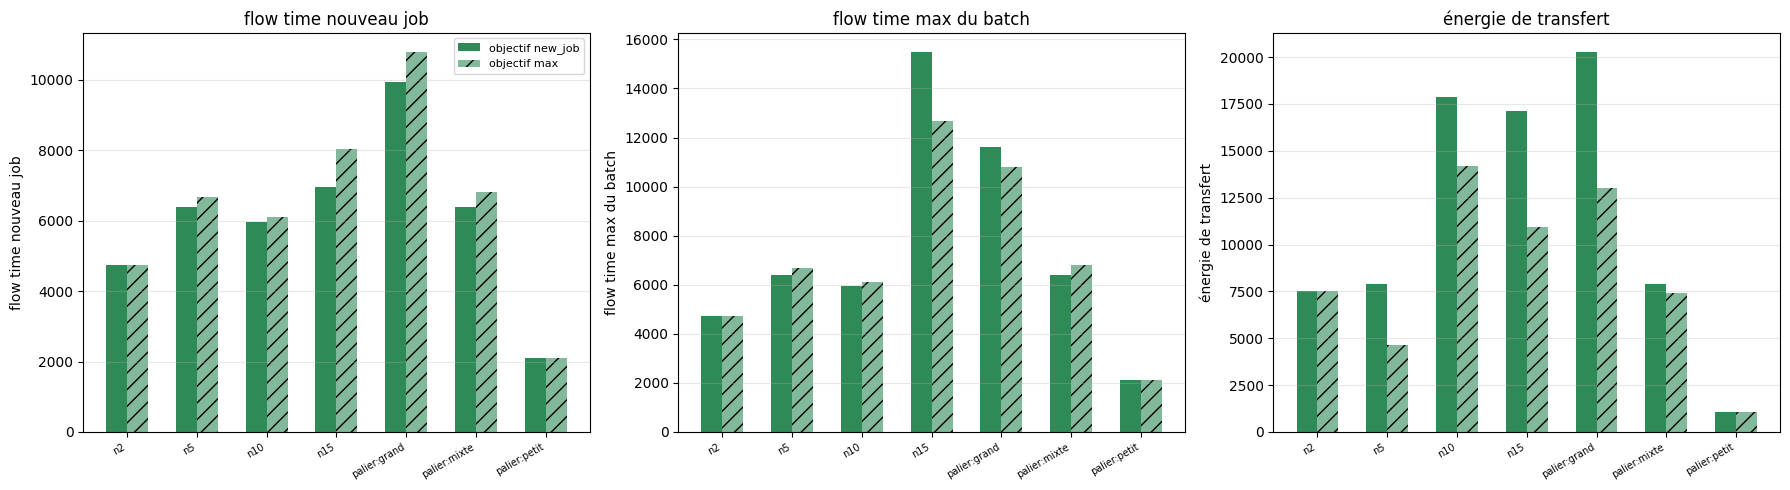

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hatch_max = "//"
metrics = [
    ("flow_time_new_job_newjob", "flow_time_new_job_max", "flow time nouveau job"),
    ("max_flow_time_all_newjob", "max_flow_time_all_max", "flow time max du batch"),
    ("transfer_energy_total_newjob", "transfer_energy_total_max", "énergie de transfert"),
]
scenarios = sorted(cmp_hyb_obj["scenario"].unique(), key=lambda s: (len(s), s))
x = np.arange(len(scenarios))
width = 0.3
hyb_color = colors["Hybrid-n_j"]
for ax, (col_nj, col_mx, ylabel) in zip(axes, metrics):
    sub = cmp_hyb_obj.set_index("scenario").reindex(scenarios)
    ax.bar(x - width / 2, sub[col_nj].values, width, color=hyb_color, label="objectif new_job")
    ax.bar(x + width / 2, sub[col_mx].values, width, color=hyb_color, hatch=hatch_max, alpha=0.6, label="objectif max")
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=30, ha="right", fontsize=7)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.grid(axis="y", alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [40]:
detail_cols_hyb = ["scenario", "flow_time_new_job_newjob", "flow_time_new_job_max",
                    "max_flow_time_all_newjob", "max_flow_time_all_max",
                    "transfer_energy_total_newjob", "transfer_energy_total_max"]
cmp_hyb_obj[detail_cols_hyb].round(1).set_index("scenario")

,flow_time_new_job_newjob,flow_time_new_job_max,max_flow_time_all_newjob,max_flow_time_all_max,transfer_energy_total_newjob,transfer_energy_total_max
scenario,,,,,,
palier:petit,2106.0,2106.0,2106.0,2106.0,1066.8,1066.8
palier:grand,9946.0,10799.0,11631.0,10799.0,20280.4,13008.9
palier:mixte,6379.0,6816.0,6379.0,6816.0,7885.3,7398.5
n2,4730.0,4730.0,4730.0,4730.0,7534.3,7534.3
n5,6379.0,6671.0,6379.0,6671.0,7885.3,4623.0
n10,5967.0,6099.0,5967.0,6099.0,17877.4,14188.1
n15,6953.0,8050.0,15492.5,12693.0,17104.9,10922.1


In [41]:
cmp_hyb_obj[["flow_time_new_job_newjob", "flow_time_new_job_max",
             "max_flow_time_all_newjob", "max_flow_time_all_max",
             "transfer_energy_total_newjob", "transfer_energy_total_max"]].mean().round(1)

flow_time_new_job_newjob         6065.7
flow_time_new_job_max            6467.3
max_flow_time_all_newjob         7526.4
max_flow_time_all_max            7130.6
transfer_energy_total_newjob    11376.3
transfer_energy_total_max        8391.7
dtype: float64

### Points clés

- L'objectif `new_job` cible spécifiquement le nouveau job (flow time nouveau job généralement
  plus bas) mais n'a aucune contrainte sur le flow time max du batch entier.
- L'objectif `max` fait l'inverse : il optimise le pire cas du batch, potentiellement au prix du
  nouveau job lui-même.
- Comparer les deux colonnes `max_flow_time_all_*` montre si cibler le nouveau job dégrade
  réellement le pire cas du batch, ou si les deux objectifs convergent souvent vers un plan
  similaire.

## 16. Front de Pareto — flow time nouveau job vs énergie (2026-10-09)

Incremental / Online_newjob / Hybrid-n_j, scénarios Phase A (palier seul) + Phase B -- même
périmètre que les sections 13/14/15. Un point par (scénario, approche) ; la ligne en escalier
relie les points non dominés (aucun autre point n'est à la fois meilleur en flow time ET en
énergie) -- le vrai front de Pareto, tous scénarios confondus. Une comparaison mono-objectif puis
bi-objectif, même construction.

In [42]:
def pareto_frontier(points):
    """points: liste de (x, y), les deux a minimiser. Retourne les points non domines, tries par x."""
    pts = sorted(points, key=lambda p: p[0])
    frontier = []
    best_y = float("inf")
    for x, y in pts:
        if y < best_y:
            frontier.append((x, y))
            best_y = y
    return frontier


def pareto_plot(ax, sub, color_map, marker_map, order_list, title):
    all_points = list(zip(sub.transfer_energy_total, sub.flow_time_new_job))
    for appr in order_list:
        s = sub[sub.approach_disp == appr]
        ax.scatter(s.transfer_energy_total, s.flow_time_new_job, label=appr, color=color_map[appr],
                   marker=marker_map[appr], s=90, edgecolor="white", linewidth=0.8, zorder=3)
    frontier = pareto_frontier(all_points)
    if frontier:
        fx = [p[0] for p in frontier]
        fy = [p[1] for p in frontier]
        ax.step(fx, fy, where="post", color="#333333", linestyle="--", linewidth=1.3, zorder=2, label="front de Pareto")
    ax.set_xlabel("énergie de transfert totale")
    ax.set_ylabel("flow time -- nouveau job")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

### Mono-objectif

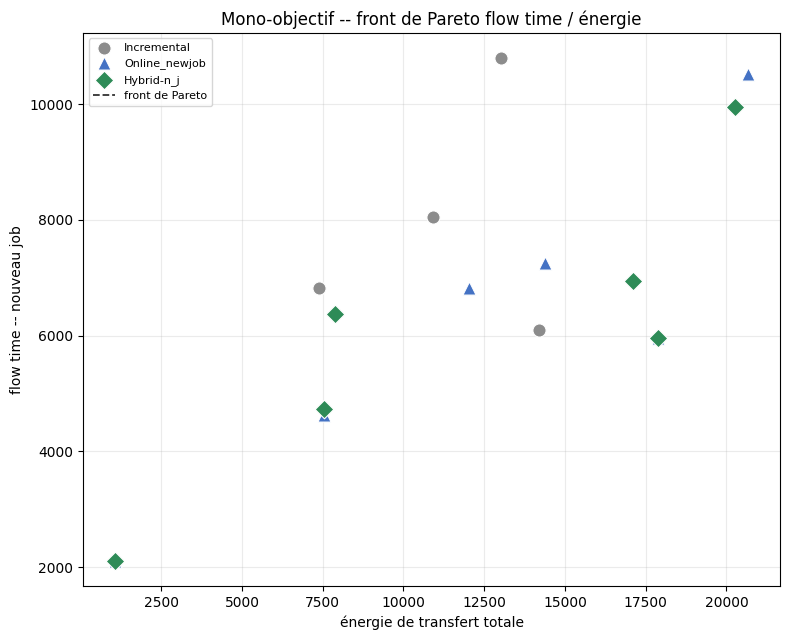

In [43]:
pareto_markers = {"Incremental": "o", "Online_newjob": "^", "Hybrid-n_j": "D"}
mono_pareto_scope = df[(df.phase == "B") | ((df.phase == "A") & (df.group == "palier"))].copy()
mono_pareto_scope["scenario"] = mono_pareto_scope.apply(scenario_label, axis=1)

fig, ax = plt.subplots(figsize=(8, 6.5))
pareto_plot(ax, mono_pareto_scope, colors, pareto_markers, order, "Mono-objectif -- front de Pareto flow time / énergie")
plt.tight_layout()
plt.show()

Même chose, scénario par scénario (Phase B seule -- n2/n5/n10/n15), chacun avec son propre front
(3 points, 1 par approche).

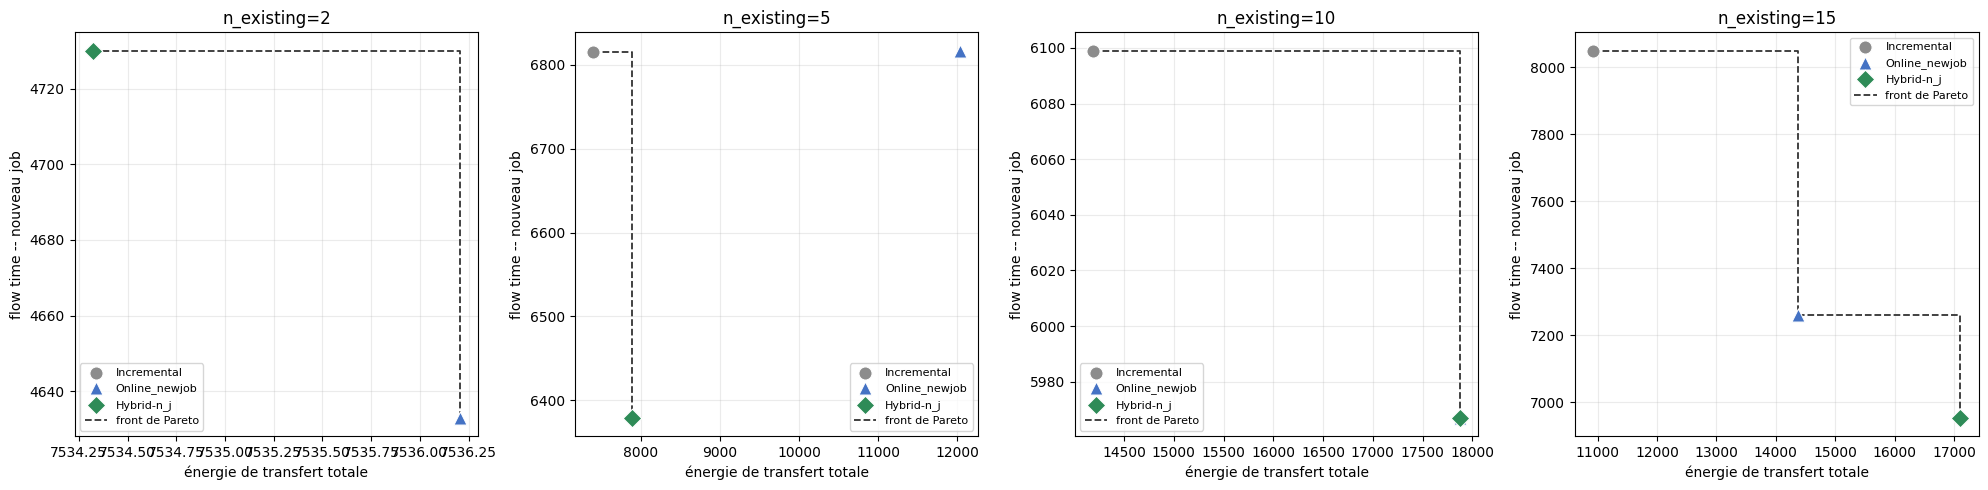

In [44]:
mono_pareto_B = mono_pareto_scope[mono_pareto_scope.phase == "B"]
n_existing_sorted = sorted(mono_pareto_B.n_existing.unique())
fig, axes = plt.subplots(1, len(n_existing_sorted), figsize=(5 * len(n_existing_sorted), 5), sharey=False)
for ax, n in zip(axes, n_existing_sorted):
    sub = mono_pareto_B[mono_pareto_B.n_existing == n]
    pareto_plot(ax, sub, colors, pareto_markers, order, f"n_existing={n}")
plt.tight_layout()
plt.show()

### Bi-objectif

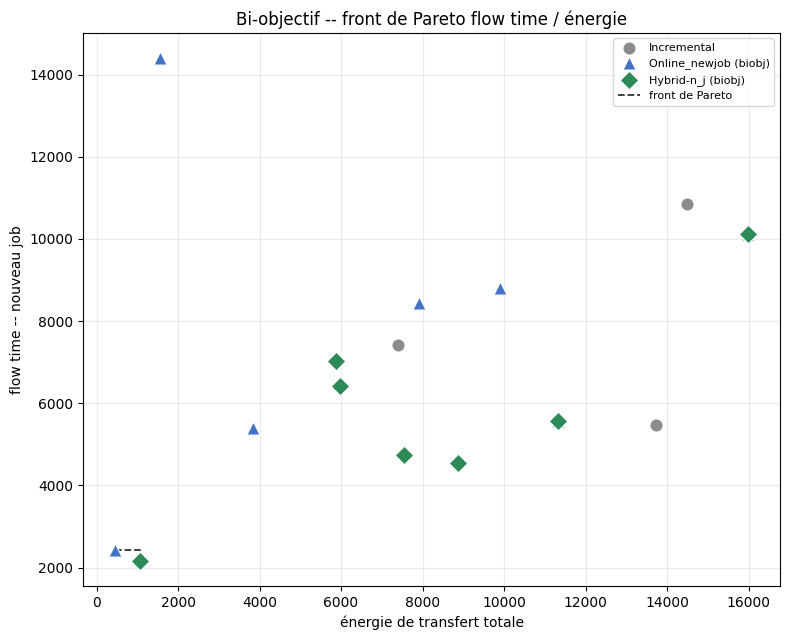

In [45]:
biobj_pareto_scope = pd.concat([df_biobj_A, df_biobj_B])

fig, ax = plt.subplots(figsize=(8, 6.5))
pareto_plot(ax, biobj_pareto_scope, biobj_colors, biobj_markers, biobj_order, "Bi-objectif -- front de Pareto flow time / énergie")
plt.tight_layout()
plt.show()

Même chose, scénario par scénario (Phase B seule -- n2/n5/n10/n15).

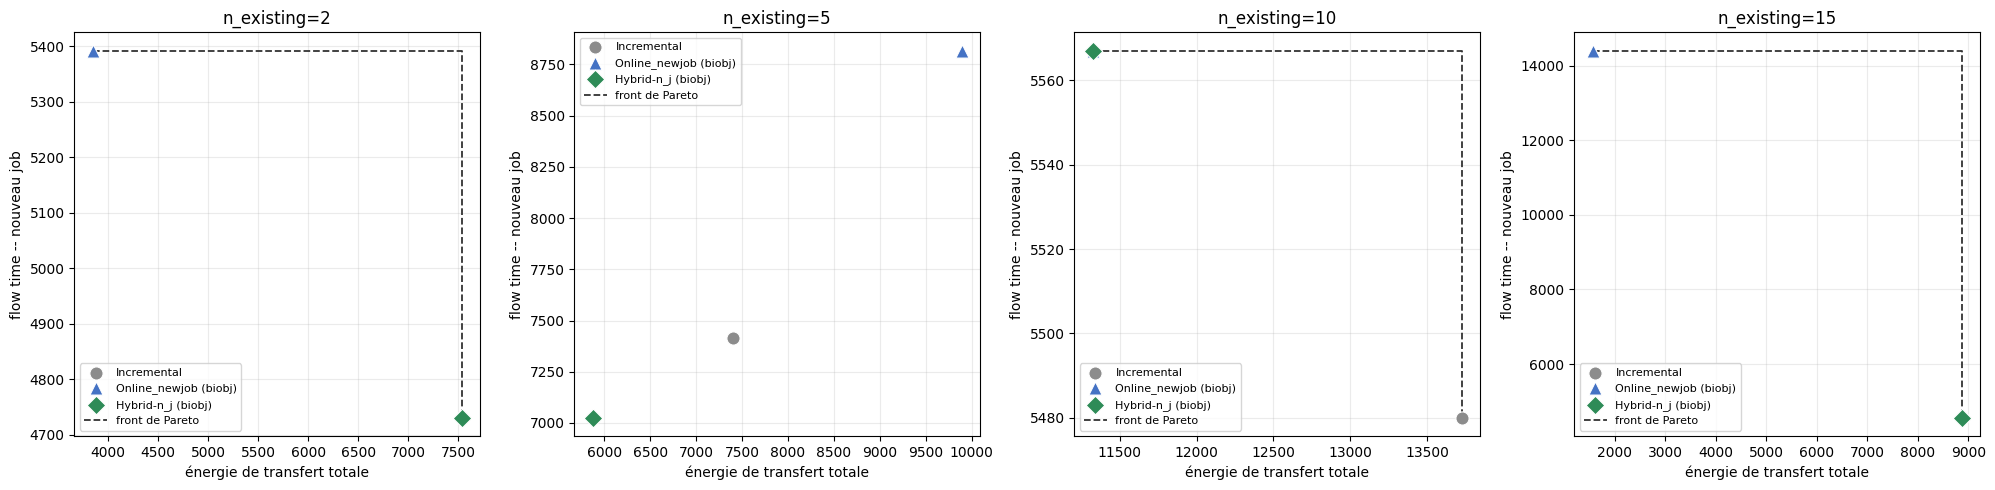

In [46]:
biobj_pareto_B = df_biobj_B.copy()
n_existing_sorted_biobj = sorted(biobj_pareto_B.n_existing.unique())
fig, axes = plt.subplots(1, len(n_existing_sorted_biobj), figsize=(5 * len(n_existing_sorted_biobj), 5), sharey=False)
for ax, n in zip(axes, n_existing_sorted_biobj):
    sub = biobj_pareto_B[biobj_pareto_B.n_existing == n]
    pareto_plot(ax, sub, biobj_colors, biobj_markers, biobj_order, f"n_existing={n}")
plt.tight_layout()
plt.show()

### Points clés

- Un point SUR le front de Pareto (relié par la ligne en escalier) n'est dominé par aucun autre
  -- aucune autre approche/scénario ne fait mieux sur les deux métriques à la fois.
- Si une approche n'apparaît presque jamais sur le front, c'est qu'elle est systématiquement
  dominée par au moins une des deux autres sur ce périmètre de scénarios -- pas forcément
  "mauvaise" dans l'absolu, juste jamais le meilleur compromis ici.